# SCAGE MPP (FreeSolv) Attention 視覺化

此 notebook 僅用於 MPP / FreeSolv attention 抽取與視覺化：

1. graph token -> atom token attention，作圖前做 min-max normalization
2. 2D 分子圖（紅色強度 + 0-1 colorbar）

> 請在 Docker `scage` container（路徑 `/workspace/`）內執行。


In [1]:
# --- Notebook 啟動位置修正 ---
# 目的：避免在 Notebook/ 目錄執行時，無法 import 專案模組
import os
import sys
from pathlib import Path


def _resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for c in candidates:
        if (c / '_config.py').exists() and (c / 'models').exists() and (c / 'data_process').exists():
            return c.resolve()
    raise RuntimeError('Cannot locate project root. Please open notebook under SCAGE project.')


PROJECT_ROOT = _resolve_project_root()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'[Init] PROJECT_ROOT = {PROJECT_ROOT}')
print(f'[Init] CWD switched to = {Path.cwd()}')

[Init] PROJECT_ROOT = /workspace
[Init] CWD switched to = /workspace


In [2]:
import os
from pathlib import Path
from copy import deepcopy
from typing import Dict, List

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

from _config import pdir, get_downstream_task_names
from data_process.compound_tools import CompoundKit, mol_to_data_pkl
from data_process.data_collator import collator_finetune_pkl
from data_process.function_group_constant import nfg
from models.scage import Scage
from models.layers.encoder import MultiScaleAttention
from utils.global_var_util import GlobalVar
from utils.userconfig_util import config_current_user, config_dataset_form

plt.rcParams['figure.dpi'] = 140
torch.set_printoptions(sci_mode=False, precision=4)
np.set_printoptions(precision=4, suppress=True)

print('cwd:', os.getcwd())

cwd: /workspace


In [3]:
def plot_raw_multiscale_attn_list(attn_per_layer: List[List[torch.Tensor]], title_prefix: str = 'Raw MultiScaleAttention attn_list', batch_idx: int = 0, max_cols: int = 4):
    """Plot full token-token raw attention heatmaps after integrating heads/scales per layer and all layers."""
    if len(attn_per_layer) == 0:
        raise RuntimeError('No attention captured. Check hook registration.')

    layer_mats = []
    for layer_idx, layer_data in enumerate(attn_per_layer):
        scale_mats = []
        raw_shapes = []
        for scale_idx, attn in enumerate(layer_data):
            raw = attn.detach().cpu()
            if raw.ndim != 4:
                raise ValueError(f'Expected attn tensor [batch, heads, tokens, tokens], got shape={tuple(raw.shape)}')
            if batch_idx < 0 or batch_idx >= raw.shape[0]:
                raise ValueError(f'batch_idx out of range: {batch_idx}, batch_size={raw.shape[0]}')

            # Integrate heads only by averaging; keep the original attention values otherwise.
            scale_mats.append(raw[batch_idx].mean(dim=0).numpy())
            raw_shapes.append(tuple(raw.shape))

        layer_mat = np.mean(scale_mats, axis=0)  # integrate multiscale branches into one matrix per layer
        layer_mats.append(layer_mat)
        print(
            f'raw attn layer={layer_idx}, shapes={raw_shapes}, '
            f'head/scale-integrated min={layer_mat.min():.6g}, max={layer_mat.max():.6g}'
        )

    integrated_mat = np.mean(layer_mats, axis=0)
    plot_mats = layer_mats + [integrated_mat]
    plot_titles = [f'Layer {idx}' for idx in range(len(layer_mats))] + ['All layers integrated']

    n_plots = len(plot_mats)
    n_cols = min(max_cols, n_plots)
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows), squeeze=False)

    for plot_idx, ax in enumerate(axes.flat):
        if plot_idx >= n_plots:
            ax.axis('off')
            continue
        mat = plot_mats[plot_idx]
        sns.heatmap(
            mat,
            cmap='Blues',
            vmin=0.0,
            vmax=1.0,
            square=True,
            ax=ax,
            cbar=True,
            xticklabels=True,
            yticklabels=True,
        )
        ax.set_title(f'{plot_titles[plot_idx]} | min={mat.min():.4g}, max={mat.max():.4g}')
        ax.set_xlabel('Key token index')
        ax.set_ylabel('Query token index')

    fig.suptitle(f'{title_prefix} | raw head/scale-integrated full attention matrices | color scale 0-1', y=1.02)
    fig.tight_layout()
    plt.show()
    print(
        f'raw attn all layers integrated, shape={integrated_mat.shape}, '
        f'min={integrated_mat.min():.6g}, max={integrated_mat.max():.6g}'
    )
    return [fig]


def plot_raw_multiscale_attn_all_heads(attn_per_layer: List[List[torch.Tensor]], title_prefix: str = 'Raw MultiScaleAttention attn_list all heads', batch_idx: int = 0, max_cols: int = 4):
    """Plot every original attn_list head matrix with a fixed 0-1 color scale."""
    if len(attn_per_layer) == 0:
        raise RuntimeError('No attention captured. Check hook registration.')

    figures = []
    for layer_idx, layer_data in enumerate(attn_per_layer):
        for scale_idx, attn in enumerate(layer_data):
            raw = attn.detach().cpu()
            if raw.ndim != 4:
                raise ValueError(f'Expected attn tensor [batch, heads, tokens, tokens], got shape={tuple(raw.shape)}')
            if batch_idx < 0 or batch_idx >= raw.shape[0]:
                raise ValueError(f'batch_idx out of range: {batch_idx}, batch_size={raw.shape[0]}')

            mats = raw[batch_idx].numpy()  # [heads, tokens, tokens], original per-head matrices
            n_heads = mats.shape[0]
            n_cols = min(max_cols, n_heads)
            n_rows = int(np.ceil(n_heads / n_cols))
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows), squeeze=False)
            dist_label = GlobalVar.dist_bar[scale_idx] if scale_idx < len(GlobalVar.dist_bar) else scale_idx

            for head_idx, ax in enumerate(axes.flat):
                if head_idx >= n_heads:
                    ax.axis('off')
                    continue
                mat = mats[head_idx]
                sns.heatmap(
                    mat,
                    cmap='Blues',
                    vmin=0.0,
                    vmax=1.0,
                    square=True,
                    ax=ax,
                    cbar=True,
                    xticklabels=True,
                    yticklabels=True,
                )
                ax.set_title(f'Head {head_idx} | min={mat.min():.4g}, max={mat.max():.4g}')
                ax.set_xlabel('Key token index')
                ax.set_ylabel('Query token index')

            fig.suptitle(
                f'{title_prefix} | layer {layer_idx} | scale {scale_idx} (dist_bar={dist_label}) | raw shape={tuple(raw.shape)} | color scale 0-1',
                y=1.02,
            )
            fig.tight_layout()
            plt.show()
            figures.append(fig)
            print(
                f'raw all-head attn layer={layer_idx}, scale={scale_idx}, dist_bar={dist_label}, '
                f'shape={tuple(raw.shape)}, min={raw.min().item():.6g}, max={raw.max().item():.6g}'
            )
    return figures

In [46]:
# ===== 使用者設定 =====
SMILES = 'CC12CC(O)C3C(CCC4=CC(=O)CCC34C)C2CCC1C(=O)CO'
TASK_NAME = 'esol'   # 此 notebook 預設用 FreeSolv finetune
GPU_ID = '0'

# 可改成你自己的 finetune 權重路徑
CKPT_PATH = f'./weights/mpp/{TASK_NAME}.pth'

# dist_bar 會從 checkpoint 還原，避免手動設定與模型訓練設定不一致。

# 可選：把結果存檔
SAVE_DIR = Path('./result/attention_vis')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_PREFIX = 'freesolv_demo'

os.environ['CUDA_VISIBLE_DEVICES'] = GPU_ID
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
print('checkpoint exists:', Path(CKPT_PATH).exists())

device: cuda
checkpoint exists: True


In [47]:
def build_runtime_config(task_name: str) -> Dict:
    cfg_path = Path(pdir) / 'config' / 'config_finetune.yaml'
    with open(cfg_path, 'r', encoding='utf-8') as f:
        cfg = yaml.load(f, Loader=yaml.FullLoader)
    cfg['task_name'] = task_name
    cfg = config_current_user('mpp', cfg)
    cfg = config_dataset_form('pkl', cfg)
    cfg = get_downstream_task_names(cfg)
    cfg['checkpoint'] = CKPT_PATH
    return cfg

def restore_dist_bar_from_ckpt(ckpt_obj):
    state = ckpt_obj.get('model', ckpt_obj)
    if not isinstance(state, dict) or 'dist_bar' not in state:
        raise RuntimeError('Checkpoint does not contain dist_bar; cannot guarantee matching multiscale attention settings.')

    dist_bar = state['dist_bar']
    if torch.is_tensor(dist_bar):
        dist_bar = dist_bar.detach().cpu().numpy().tolist()
    elif hasattr(dist_bar, 'tolist'):
        dist_bar = dist_bar.tolist()

    GlobalVar.dist_bar = list(dist_bar)
    return GlobalVar.dist_bar

def build_model(cfg: Dict, device: str = 'cuda') -> torch.nn.Module:
    model = Scage(
        mode=cfg['mode'],
        atom_names=CompoundKit.atom_vocab_dict.keys(),
        atom_embed_dim=cfg['model']['atom_embed_dim'],
        num_kernel=cfg['model']['num_kernel'],
        layer_num=cfg['model']['layer_num'],
        num_heads=cfg['model']['num_heads'],
        atom_FG_class=nfg() + 1,
        hidden_size=cfg['model']['hidden_size'],
        num_tasks=cfg['num_tasks'],
    ).to(device)
    ckpt = torch.load(cfg['checkpoint'], map_location=device)
    state = ckpt.get('model', ckpt)
    state = {k[7:] if k.startswith('module.') else k: v for k, v in state.items()}
    cur = model.state_dict()
    cur.update({k: v for k, v in state.items() if k in cur})
    model.load_state_dict(cur)
    model.eval()
    return model

def build_single_batch(smiles: str, device: str = 'cuda') -> Dict[str, torch.Tensor]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')
    data = mol_to_data_pkl(mol)
    data['smiles'] = smiles
    data['label'] = np.array([0.0], dtype=np.float32)  # collator 需要 label
    batch = collator_finetune_pkl([data])
    batch = {k: v.to(device) for k, v in batch.items() if v is not None and not isinstance(v, list)}
    batch['edge_weight'] = None
    return batch
def register_attention_hooks(model: torch.nn.Module, sink: List[List[torch.Tensor]]):
    hooks = []
    def _hook(_, __, out):
        # MultiScaleAttention.forward -> (x, attn_list)
        attn_list = out[1]
        sink.append([a.detach().cpu() for a in attn_list])
    for m in model.modules():
        if isinstance(m, MultiScaleAttention):
            hooks.append(m.register_forward_hook(_hook))
    return hooks
def _minmax_normalize_scores(score: np.ndarray, axis: int = -1) -> np.ndarray:
    """Scale attention scores to 0-1 before heatmap/molecule coloring."""
    score = np.asarray(score, dtype=float)
    score_min = score.min(axis=axis, keepdims=True)
    score_max = score.max(axis=axis, keepdims=True)
    return (score - score_min) / (score_max - score_min + 1e-12)


def aggregate_attention(attn_per_layer: List[List[torch.Tensor]], n_atoms: int, layer_idx: int = None):
    if len(attn_per_layer) == 0:
        raise RuntimeError('No attention captured. Check hook registration.')

    # Paper-style: graph token (token 0) -> atom tokens (token 1~N).
    # Per layer: average heads first, then average multiscale branches.
    layer_scores = []
    for layer_data in attn_per_layer:
        scale_scores = []
        for dist_attn in layer_data:
            # shape: [batch, heads, tokens, tokens] -> [batch, atoms]
            score = dist_attn[:, :, 0, 1:n_atoms + 1].mean(dim=1)
            scale_scores.append(score)
        layer_scores.append(torch.stack(scale_scores, dim=0).mean(dim=0))

    # layer_idx=None: all-layer aggregated score; otherwise selected single layer.
    if layer_idx is None:
        selected_score = torch.stack(layer_scores, dim=0).mean(dim=0)
    else:
        if layer_idx < 0 or layer_idx >= len(layer_scores):
            raise ValueError(f'layer_idx out of range: {layer_idx}, total layers={len(layer_scores)}')
        selected_score = layer_scores[layer_idx]

    selected_score_np = selected_score.numpy()
    atom_score_raw = selected_score_np[0]
    atom_score = _minmax_normalize_scores(selected_score_np)[0]
    per_layer_scores = [_minmax_normalize_scores(score.numpy())[0] for score in layer_scores]

    # 1D atom score 用單列 heatmap 顯示，避免回到 atom-atom [N,N] matrix。
    atom_heatmap = atom_score.reshape(1, -1)
    layer_heatmaps = [score.reshape(1, -1) for score in per_layer_scores]
    return atom_heatmap, atom_score_raw, atom_score, layer_heatmaps


def compute_bond_scores(smiles: str, atom_scores: np.ndarray):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')
    atom_scores = np.asarray(atom_scores, dtype=float)
    bond_scores = []
    bond_indices = []
    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        bond_indices.append((a1, a2))
        bond_scores.append((atom_scores[a1] + atom_scores[a2]) / 2.0)
    return np.asarray(bond_scores, dtype=float).reshape(1, -1), bond_indices


## 第一章：Graph Token -> Atom Attention（新版邏輯）

此章節使用新版 graph token 對 atom token 的 attention 作為 FreeSolv / MPP 的 atom score。

流程會：

1. 載入 MPP finetune checkpoint
2. 擷取 attention（softmax 後）
3. 取 graph token 對 atom token 的 attention，並在作圖前做 min-max normalization
4. 輸出 0-1 固定色階的 atom heatmap
5. 輸出結構圖（紅色強度 + 0-1 colorbar）

In [48]:
cfg = build_runtime_config(TASK_NAME)
ckpt_obj = torch.load(cfg['checkpoint'], map_location=DEVICE)
restored_dist_bar = restore_dist_bar_from_ckpt(ckpt_obj)
print('restored dist_bar from checkpoint:', restored_dist_bar)
model = build_model(cfg, device=DEVICE)
batch = build_single_batch(SMILES, device=DEVICE)

attn_sink = []
hooks = register_attention_hooks(model, attn_sink)
with torch.no_grad():
    out = model(batch)
for h in hooks:
    h.remove()

pred = out['graph_feature'].view(-1).cpu().numpy()[0]
n_atoms = int(batch['atom_length'][0].item())
(
    atom_heatmap,
    atom_scores_raw,
    atom_scores,
    atom_layer_heatmaps,
) = aggregate_attention(attn_sink, n_atoms=n_atoms)
final_layer_idx = len(atom_layer_heatmaps) - 1
(
    final_heatmap,
    final_atom_scores_raw,
    final_atom_scores,
    _,
) = aggregate_attention(
    attn_sink,
    n_atoms=n_atoms,
    layer_idx=final_layer_idx,
)
bond_scores, bond_indices = compute_bond_scores(SMILES, atom_scores)
attention_result = {
    'per_layer_minmax': [h.reshape(-1) for h in atom_layer_heatmaps],
    'aggregated_raw': atom_scores_raw,
    'aggregated_minmax': atom_scores,
    'final_layer_raw': final_atom_scores_raw,
    'final_layer_minmax': final_atom_scores,
    'bond_score_minmax': bond_scores,
    'bond_index': bond_indices,
    'smiles': SMILES,
    'image_paths': {},
}

print('SMILES:', SMILES)
print('pred(graph_feature):', float(pred))
print('num_atoms:', n_atoms)
print('aggregated atom_scores raw:', np.round(atom_scores_raw, 6))
print('aggregated atom_scores min-max:', np.round(atom_scores, 4))
print(f'final-layer atom_scores raw (layer {final_layer_idx}):', np.round(final_atom_scores_raw, 6))
print(f'final-layer atom_scores min-max (layer {final_layer_idx}):', np.round(final_atom_scores, 4))

restored dist_bar from checkpoint: [10, 90]
SMILES: CC12CC(O)C3C(CCC4=CC(=O)CCC34C)C2CCC1C(=O)CO
pred(graph_feature): -4.26217794418335
num_atoms: 25
aggregated atom_scores raw: [0.0221 0.0382 0.028  0.0452 0.0606 0.0389 0.0354 0.0259 0.0226 0.0281
 0.0248 0.0257 0.0443 0.0224 0.0241 0.0429 0.0219 0.0541 0.0249 0.0261
 0.0502 0.0359 0.0434 0.0464 0.065 ]
aggregated atom_scores min-max: [0.0025 0.3776 0.1409 0.5392 0.8985 0.3941 0.3123 0.0924 0.0154 0.1423
 0.0652 0.0866 0.5179 0.0107 0.0501 0.4861 0.     0.7455 0.0686 0.097
 0.6569 0.324  0.4989 0.567  1.    ]
final-layer atom_scores raw (layer 5): [0.0058 0.031  0.0155 0.1041 0.0325 0.0481 0.0367 0.0176 0.0121 0.0312
 0.0218 0.0125 0.0403 0.012  0.0124 0.0799 0.0055 0.0539 0.015  0.0145
 0.0916 0.0322 0.041  0.0693 0.0594]
final-layer atom_scores min-max (layer 5): [0.0037 0.2588 0.1014 1.     0.2742 0.4324 0.3164 0.1229 0.0675 0.261
 0.166  0.0716 0.3536 0.0661 0.0706 0.7551 0.     0.491  0.0968 0.0918
 0.8735 0.2711 0.36   0.6471 0.

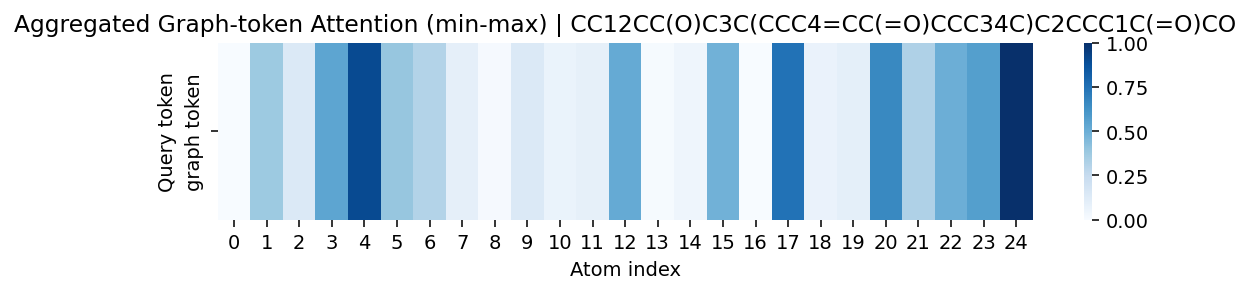

saved: result/attention_vis/freesolv_demo_heatmap.png


In [49]:
# 1) all-layer aggregated graph-token -> atom attention heatmap（min-max normalization）
plt.figure(figsize=(8.0, 2.2))
sns.heatmap(
    atom_heatmap,
    cmap='Blues',
    vmin=0.0,
    vmax=1.0,
    square=False,
    xticklabels=[str(i) for i in range(atom_heatmap.shape[1])],
    yticklabels=['graph token'],
)
plt.title(f'Aggregated Graph-token Attention (min-max) | {SMILES}')
plt.xlabel('Atom index')
plt.ylabel('Query token')
plt.tight_layout()
heatmap_path = SAVE_DIR / f'{SAVE_PREFIX}_heatmap.png'
plt.savefig(heatmap_path, dpi=200)
attention_result['image_paths']['aggregated_heatmap'] = str(heatmap_path)
plt.show()
print('saved:', heatmap_path)


In [50]:
def draw_attention_on_molecule(smiles: str, atom_scores: np.ndarray, size=(700, 420)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')
    Chem.rdDepictor.Compute2DCoords(mol)
    n_atoms = mol.GetNumAtoms()
    if len(atom_scores) != n_atoms:
        raise ValueError(f'atom_scores length {len(atom_scores)} != num_atoms {n_atoms}')
    # atom_scores 已在 attention aggregation 階段依 min-max normalization 到 0~1。
    atom_scores = np.clip(np.asarray(atom_scores, dtype=float), 0.0, 1.0)
    # Atom 顏色：紅色 alpha = atom score
    highlight_atoms = list(range(n_atoms))
    atom_cols = {
        i: (1.0, 0.0, 0.0, float(atom_scores[i]))
        for i in highlight_atoms
    }
    # Bond 顏色：edge score = 兩端 atom score 平均
    highlight_bonds = []
    bond_cols = {}
    for bond in mol.GetBonds():
        b_idx = bond.GetIdx()
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        edge_score = float((atom_scores[a1] + atom_scores[a2]) / 2.0)
        highlight_bonds.append(b_idx)
        bond_cols[b_idx] = (1.0, 0.0, 0.0, edge_score)
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    opts = drawer.drawOptions()
    opts.useBWAtomPalette()  # 原子元素顏色統一黑色（如 C/H/O）
    opts.addAtomIndices = False
    opts.bondLineWidth = 2
    opts.highlightRadius = 0.42
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_cols,
        highlightBonds=highlight_bonds,
        highlightBondColors=bond_cols,
    )
    drawer.FinishDrawing()
    return drawer.GetDrawingText()


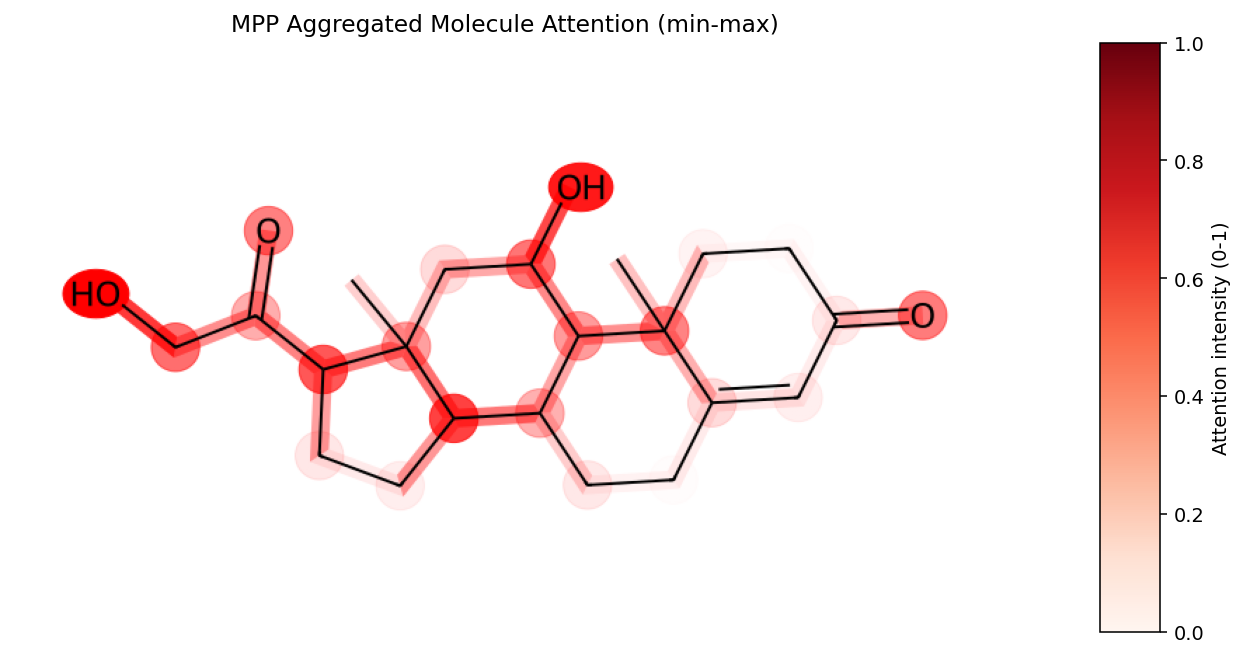

saved: result/attention_vis/freesolv_demo_mol_attention.png

Atom score list (raw vs min-max):
atom  0: raw=0.022052 | min-max=0.0025
atom  1: raw=0.038211 | min-max=0.3776
atom  2: raw=0.028015 | min-max=0.1409
atom  3: raw=0.045172 | min-max=0.5392
atom  4: raw=0.060648 | min-max=0.8985
atom  5: raw=0.038921 | min-max=0.3941
atom  6: raw=0.035396 | min-max=0.3123
atom  7: raw=0.025923 | min-max=0.0924
atom  8: raw=0.022607 | min-max=0.0154
atom  9: raw=0.028074 | min-max=0.1423
atom 10: raw=0.024755 | min-max=0.0652
atom 11: raw=0.025677 | min-max=0.0866
atom 12: raw=0.044252 | min-max=0.5179
atom 13: raw=0.022405 | min-max=0.0107
atom 14: raw=0.024103 | min-max=0.0501
atom 15: raw=0.042883 | min-max=0.4861
atom 16: raw=0.021945 | min-max=0.0000
atom 17: raw=0.054057 | min-max=0.7455
atom 18: raw=0.024899 | min-max=0.0686
atom 19: raw=0.026123 | min-max=0.0970
atom 20: raw=0.050239 | min-max=0.6569
atom 21: raw=0.035899 | min-max=0.3240
atom 22: raw=0.043436 | min-max=0.4989
atom 23:

In [51]:
# Aggregated molecule attention + atom index 與 score 對照表（保留原始位置）
img_bytes = draw_attention_on_molecule(SMILES, atom_scores)
png_path = SAVE_DIR / f'{SAVE_PREFIX}_mol_attention.png'
with open(png_path, 'wb') as f:
    f.write(img_bytes)
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.8), gridspec_kw={'width_ratios': [20, 1]})
axes[0].imshow(plt.imread(str(png_path)))
axes[0].axis('off')
axes[0].set_title('MPP Aggregated Molecule Attention (min-max)')
norm = plt.Normalize(0.0, 1.0)
sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=axes[1])
cbar.set_label('Attention intensity (0-1)')
plt.tight_layout()
attention_result['image_paths']['aggregated_mol'] = str(png_path)
plt.show()
print('saved:', png_path)

print('\nAtom score list (raw vs min-max):')
for i, (s_raw, s_minmax) in enumerate(zip(atom_scores_raw, atom_scores)):
    print(f'atom {i:>2d}: raw={s_raw:.6f} | min-max={s_minmax:.4f}')


Render per-layer heatmaps and molecule attention plots (no file export) ...


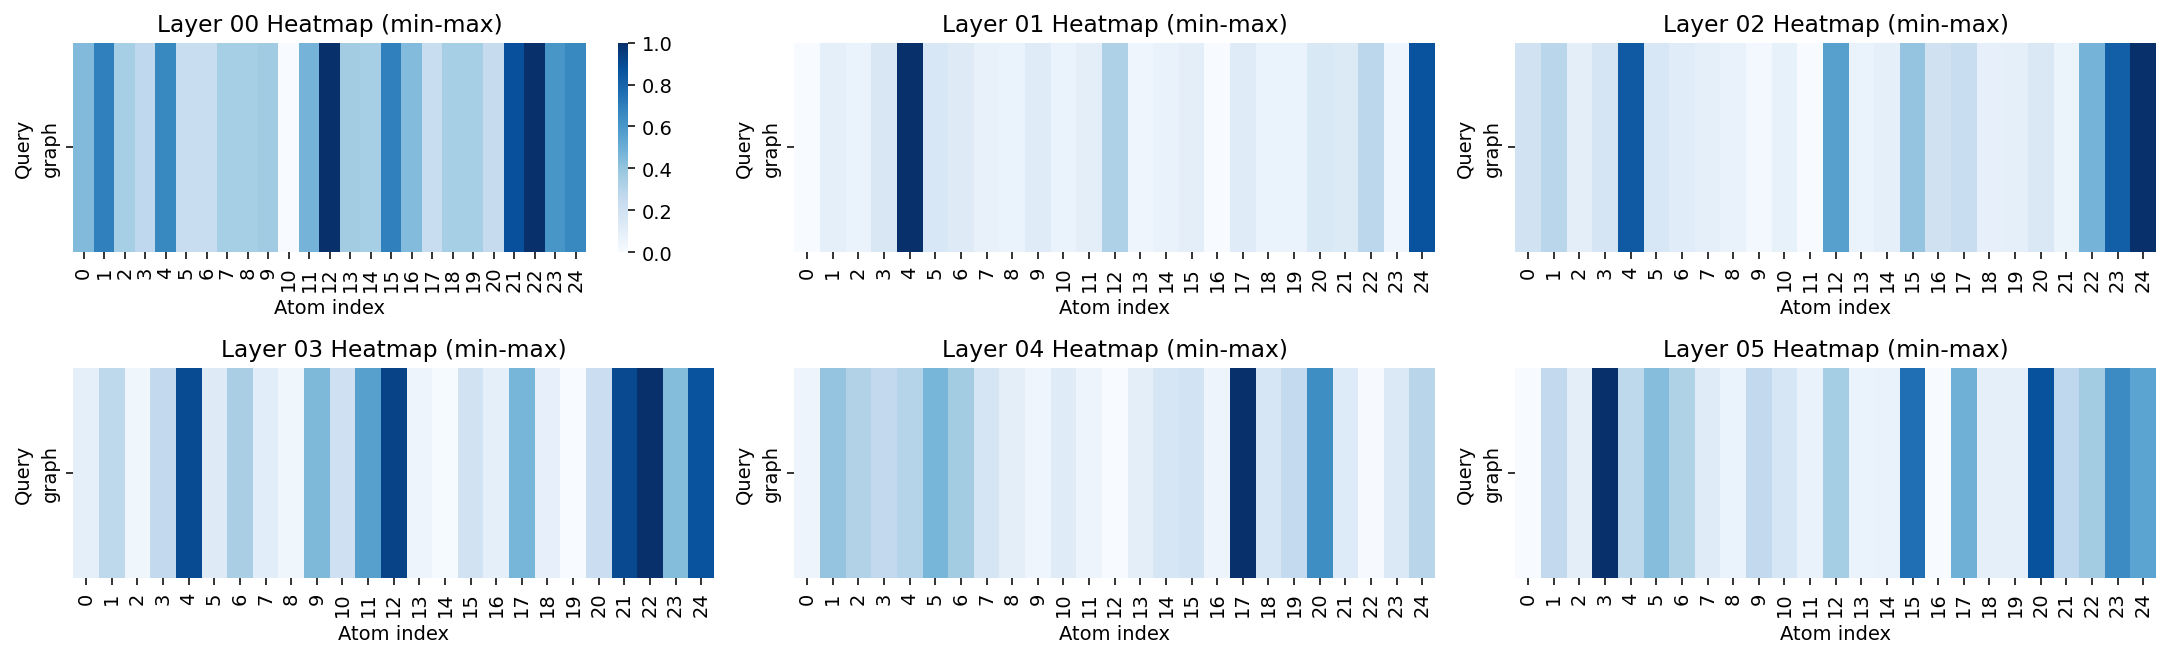

layer 00 rendered (in-memory)
layer 01 rendered (in-memory)
layer 02 rendered (in-memory)
layer 03 rendered (in-memory)
layer 04 rendered (in-memory)
layer 05 rendered (in-memory)
Total rendered: 6 layer plots


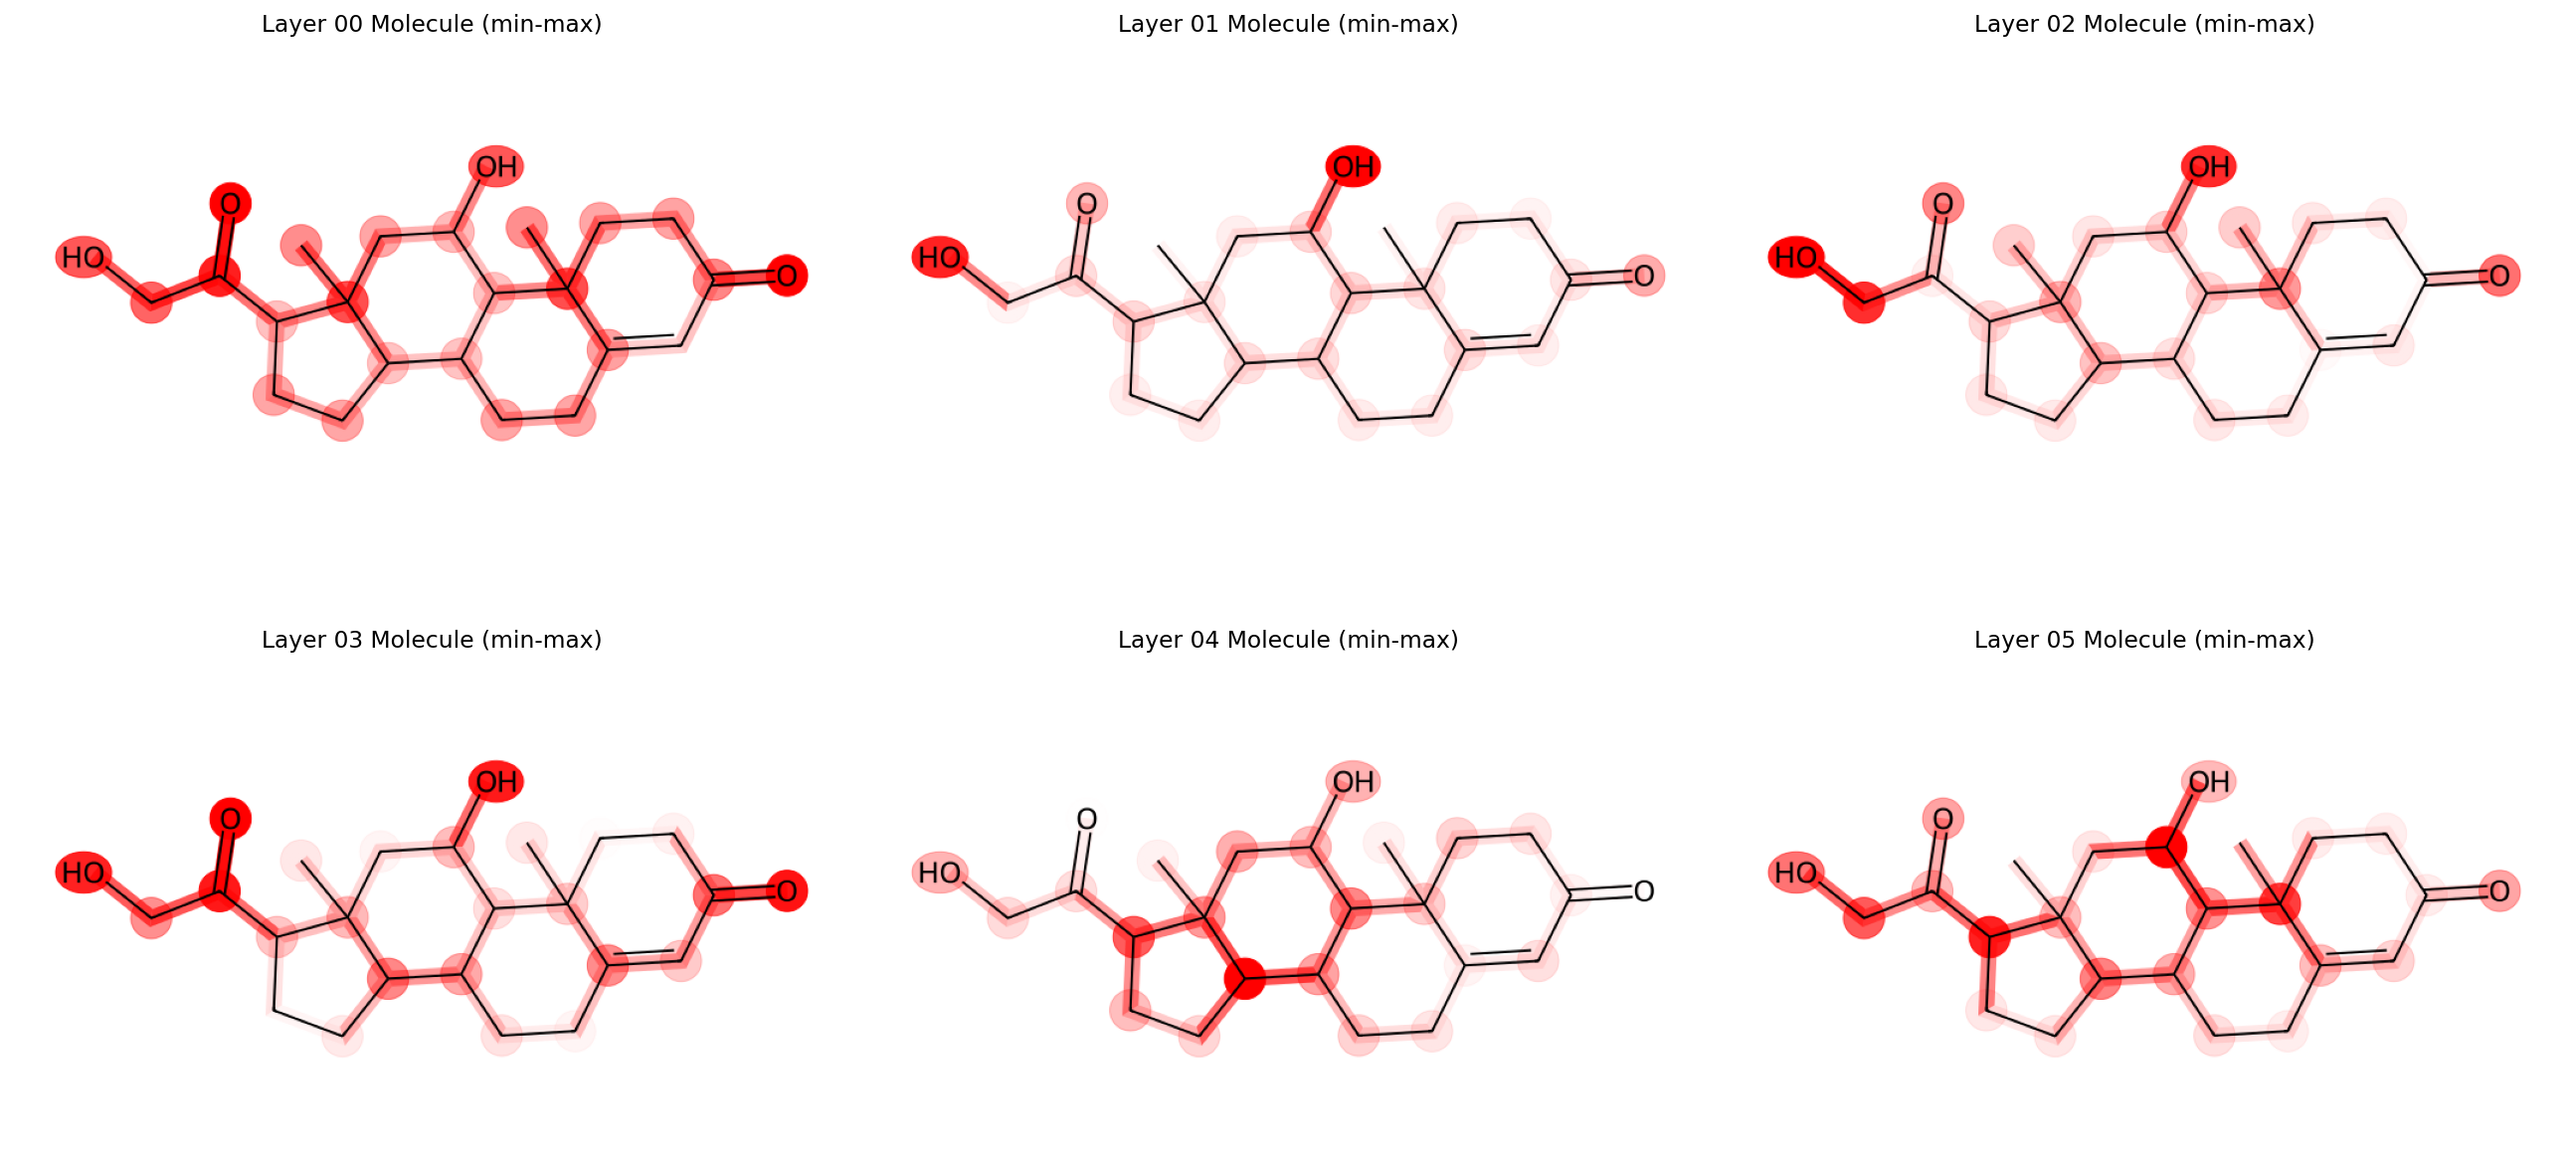

In [52]:
# 自動迴圈：逐層生成 attention 圖（heatmap + 分子結構，僅顯示，不寫檔）
print('\nRender per-layer heatmaps and molecule attention plots (no file export) ...')
from io import BytesIO

n_layers = len(atom_layer_heatmaps)

# A) 每層 heatmap
heat_cols = min(3, n_layers)
heat_rows = int(np.ceil(n_layers / heat_cols))
fig, axes = plt.subplots(heat_rows, heat_cols, figsize=(5.2 * heat_cols, 2.4 * heat_rows))
axes = np.array(axes).reshape(-1)
for i in range(n_layers):
    sns.heatmap(
        atom_layer_heatmaps[i],
        cmap='Blues',
        vmin=0.0,
        vmax=1.0,
        square=False,
        xticklabels=[str(j) for j in range(atom_layer_heatmaps[i].shape[1])],
        yticklabels=['graph'],
        cbar=(i == 0),
        ax=axes[i],
    )
    axes[i].set_title(f'Layer {i:02d} Heatmap (min-max)')
    axes[i].set_xlabel('Atom index')
    axes[i].set_ylabel('Query')
for j in range(n_layers, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# B) 每層分子結構 attention 圖（in-memory）
per_layer_imgs = []
for i, layer_heatmap in enumerate(atom_layer_heatmaps):
    layer_scores = layer_heatmap.reshape(-1)
    layer_img_bytes = draw_attention_on_molecule(SMILES, layer_scores)
    per_layer_imgs.append(layer_img_bytes)
    print(f'layer {i:02d} rendered (in-memory)')
print(f'Total rendered: {len(per_layer_imgs)} layer plots')

show_cols = min(3, len(per_layer_imgs))
show_rows = int(np.ceil(len(per_layer_imgs) / show_cols))
fig, axes = plt.subplots(show_rows, show_cols, figsize=(6.2 * show_cols, 4.8 * show_rows))
axes = np.array(axes).reshape(-1)
for i, img_bytes in enumerate(per_layer_imgs):
    axes[i].imshow(plt.imread(BytesIO(img_bytes)))
    axes[i].axis('off')
    axes[i].set_title(f'Layer {i:02d} Molecule (min-max)')
for j in range(len(per_layer_imgs), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


## Raw Attention Heatmap（整合 Head / Scale / Layer）

使用 `MultiScaleAttention` hook 收到的原始 `attn_list`，先整合 head 與 multiscale branch，輸出每一層的完整 token-token raw attention matrix，最後再輸出所有 layer 整合的 matrix。色階固定為 0-1。

raw attn layer=0, shapes=[(1, 16, 9, 9), (1, 16, 9, 9)], head/scale-integrated min=0, max=0.297175
raw attn layer=1, shapes=[(1, 16, 9, 9), (1, 16, 9, 9)], head/scale-integrated min=0, max=0.318878
raw attn layer=2, shapes=[(1, 16, 9, 9), (1, 16, 9, 9)], head/scale-integrated min=0, max=0.322812
raw attn layer=3, shapes=[(1, 16, 9, 9), (1, 16, 9, 9)], head/scale-integrated min=0, max=0.310713
raw attn layer=4, shapes=[(1, 16, 9, 9), (1, 16, 9, 9)], head/scale-integrated min=0, max=0.295382
raw attn layer=5, shapes=[(1, 16, 9, 9), (1, 16, 9, 9)], head/scale-integrated min=0, max=0.335955


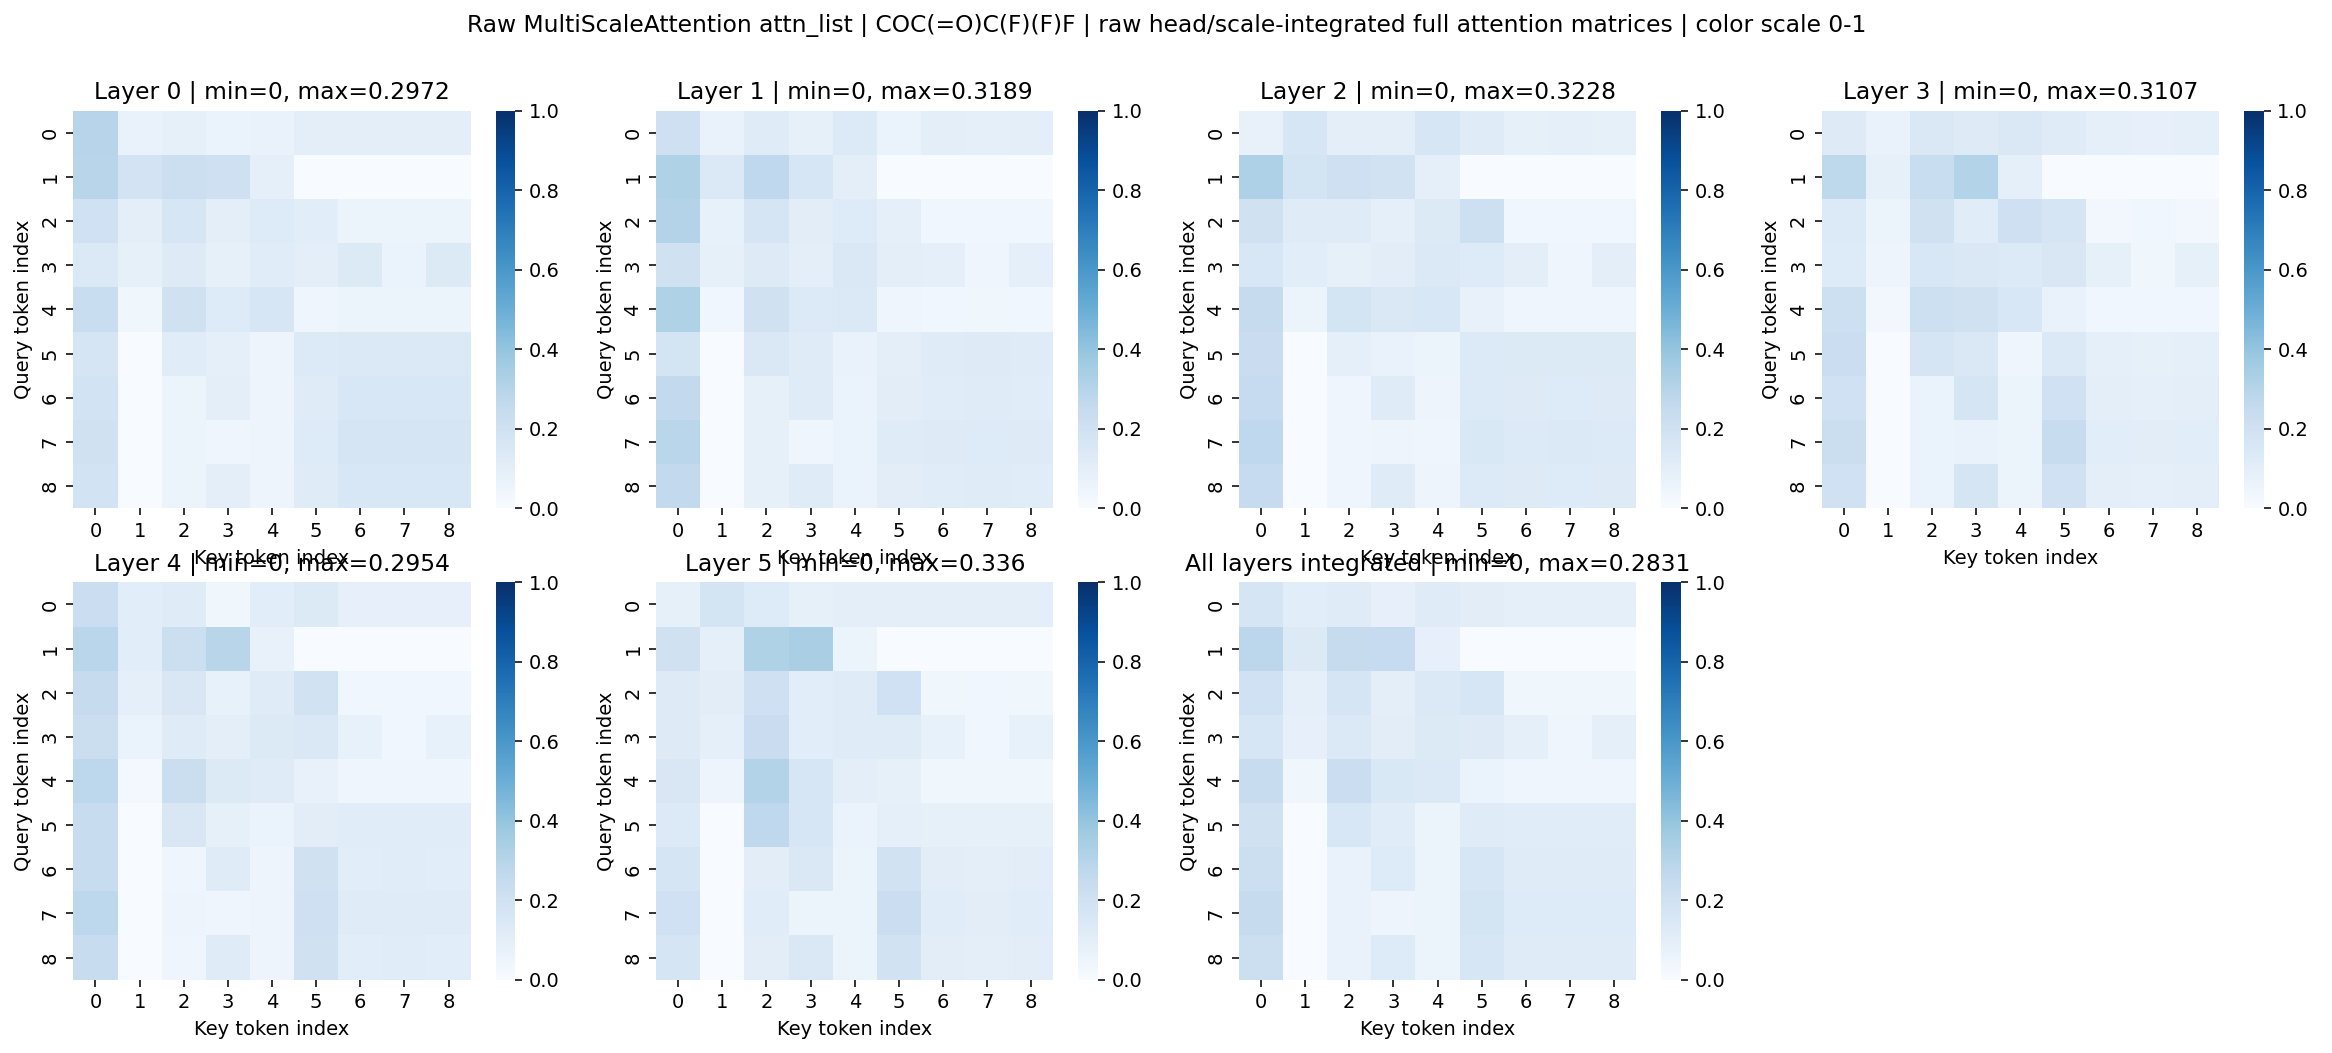

raw attn all layers integrated, shape=(9, 9), min=0, max=0.283108


In [7]:
raw_attn_figs = plot_raw_multiscale_attn_list(
    attn_sink,
    title_prefix=f'Raw MultiScaleAttention attn_list | {SMILES}',
)

## Raw Attention Heatmap（所有 Head）

直接輸出 `MultiScaleAttention` 原始 `attn_list` 的所有 head heatmap。這裡不整合 head；每個 layer、每個 multiscale branch 會各自顯示所有 head 的完整 token-token matrix。色階固定為 0-1。

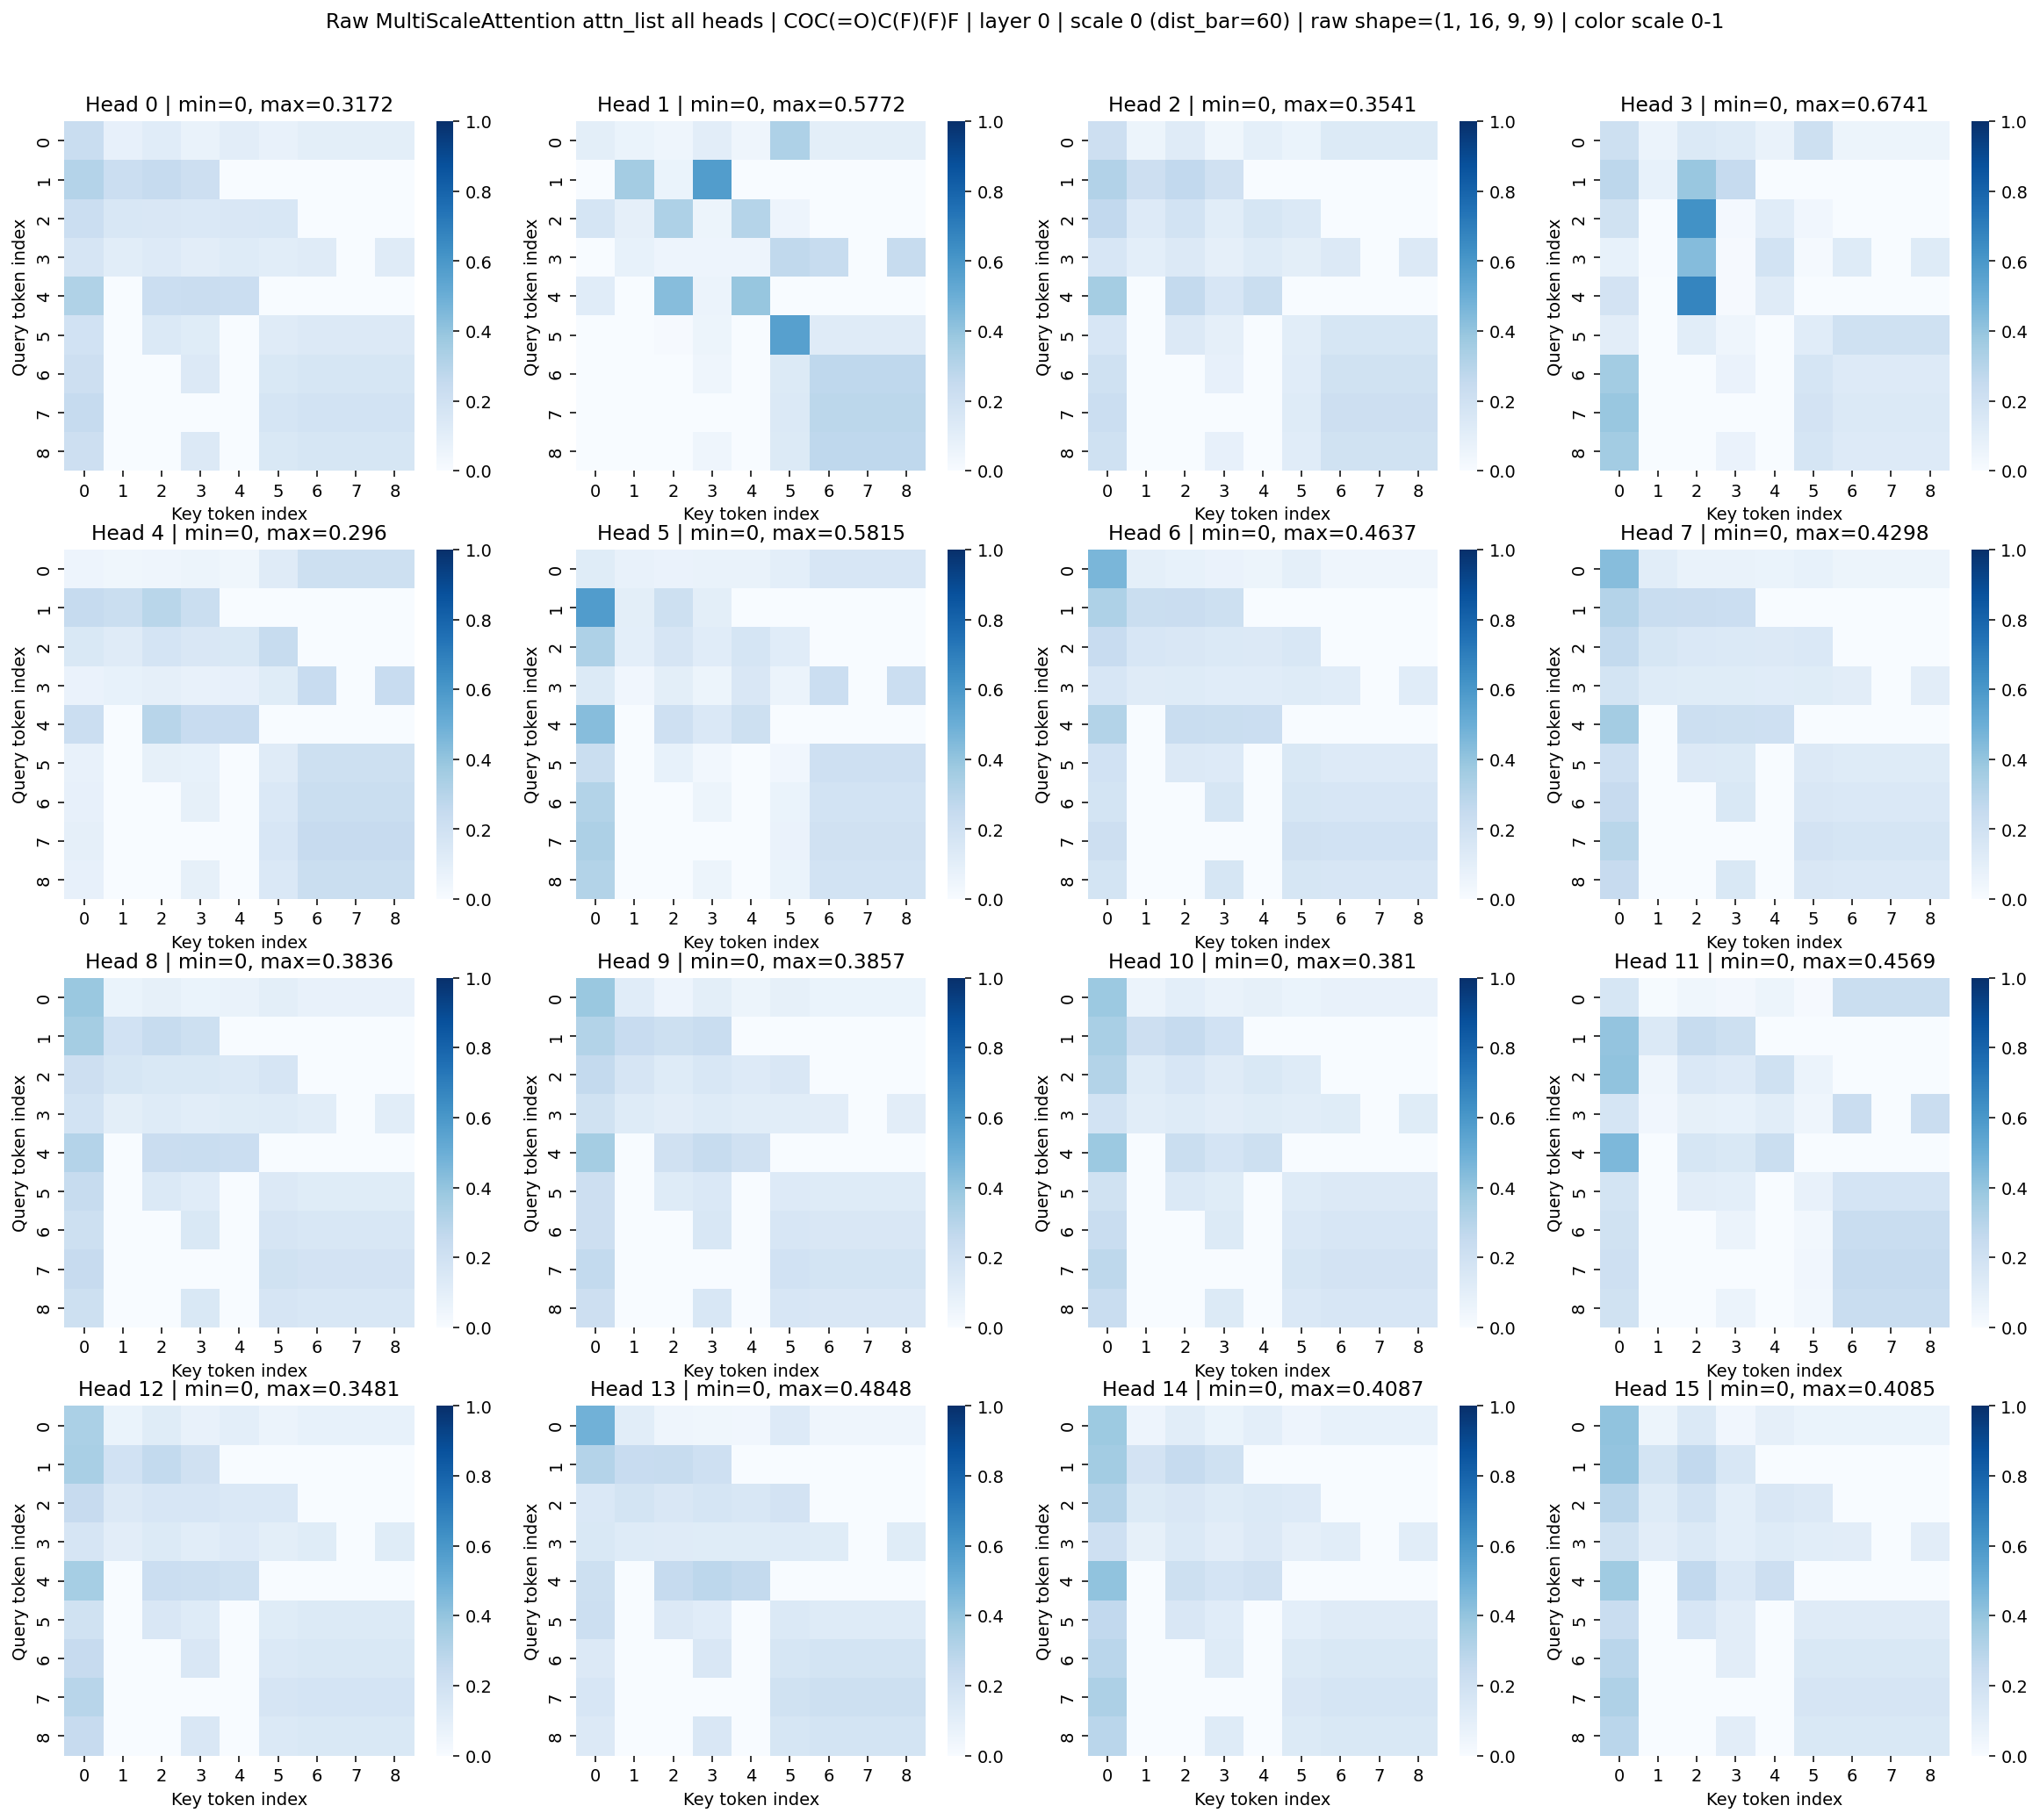

raw all-head attn layer=0, scale=0, dist_bar=60, shape=(1, 16, 9, 9), min=0, max=0.674091


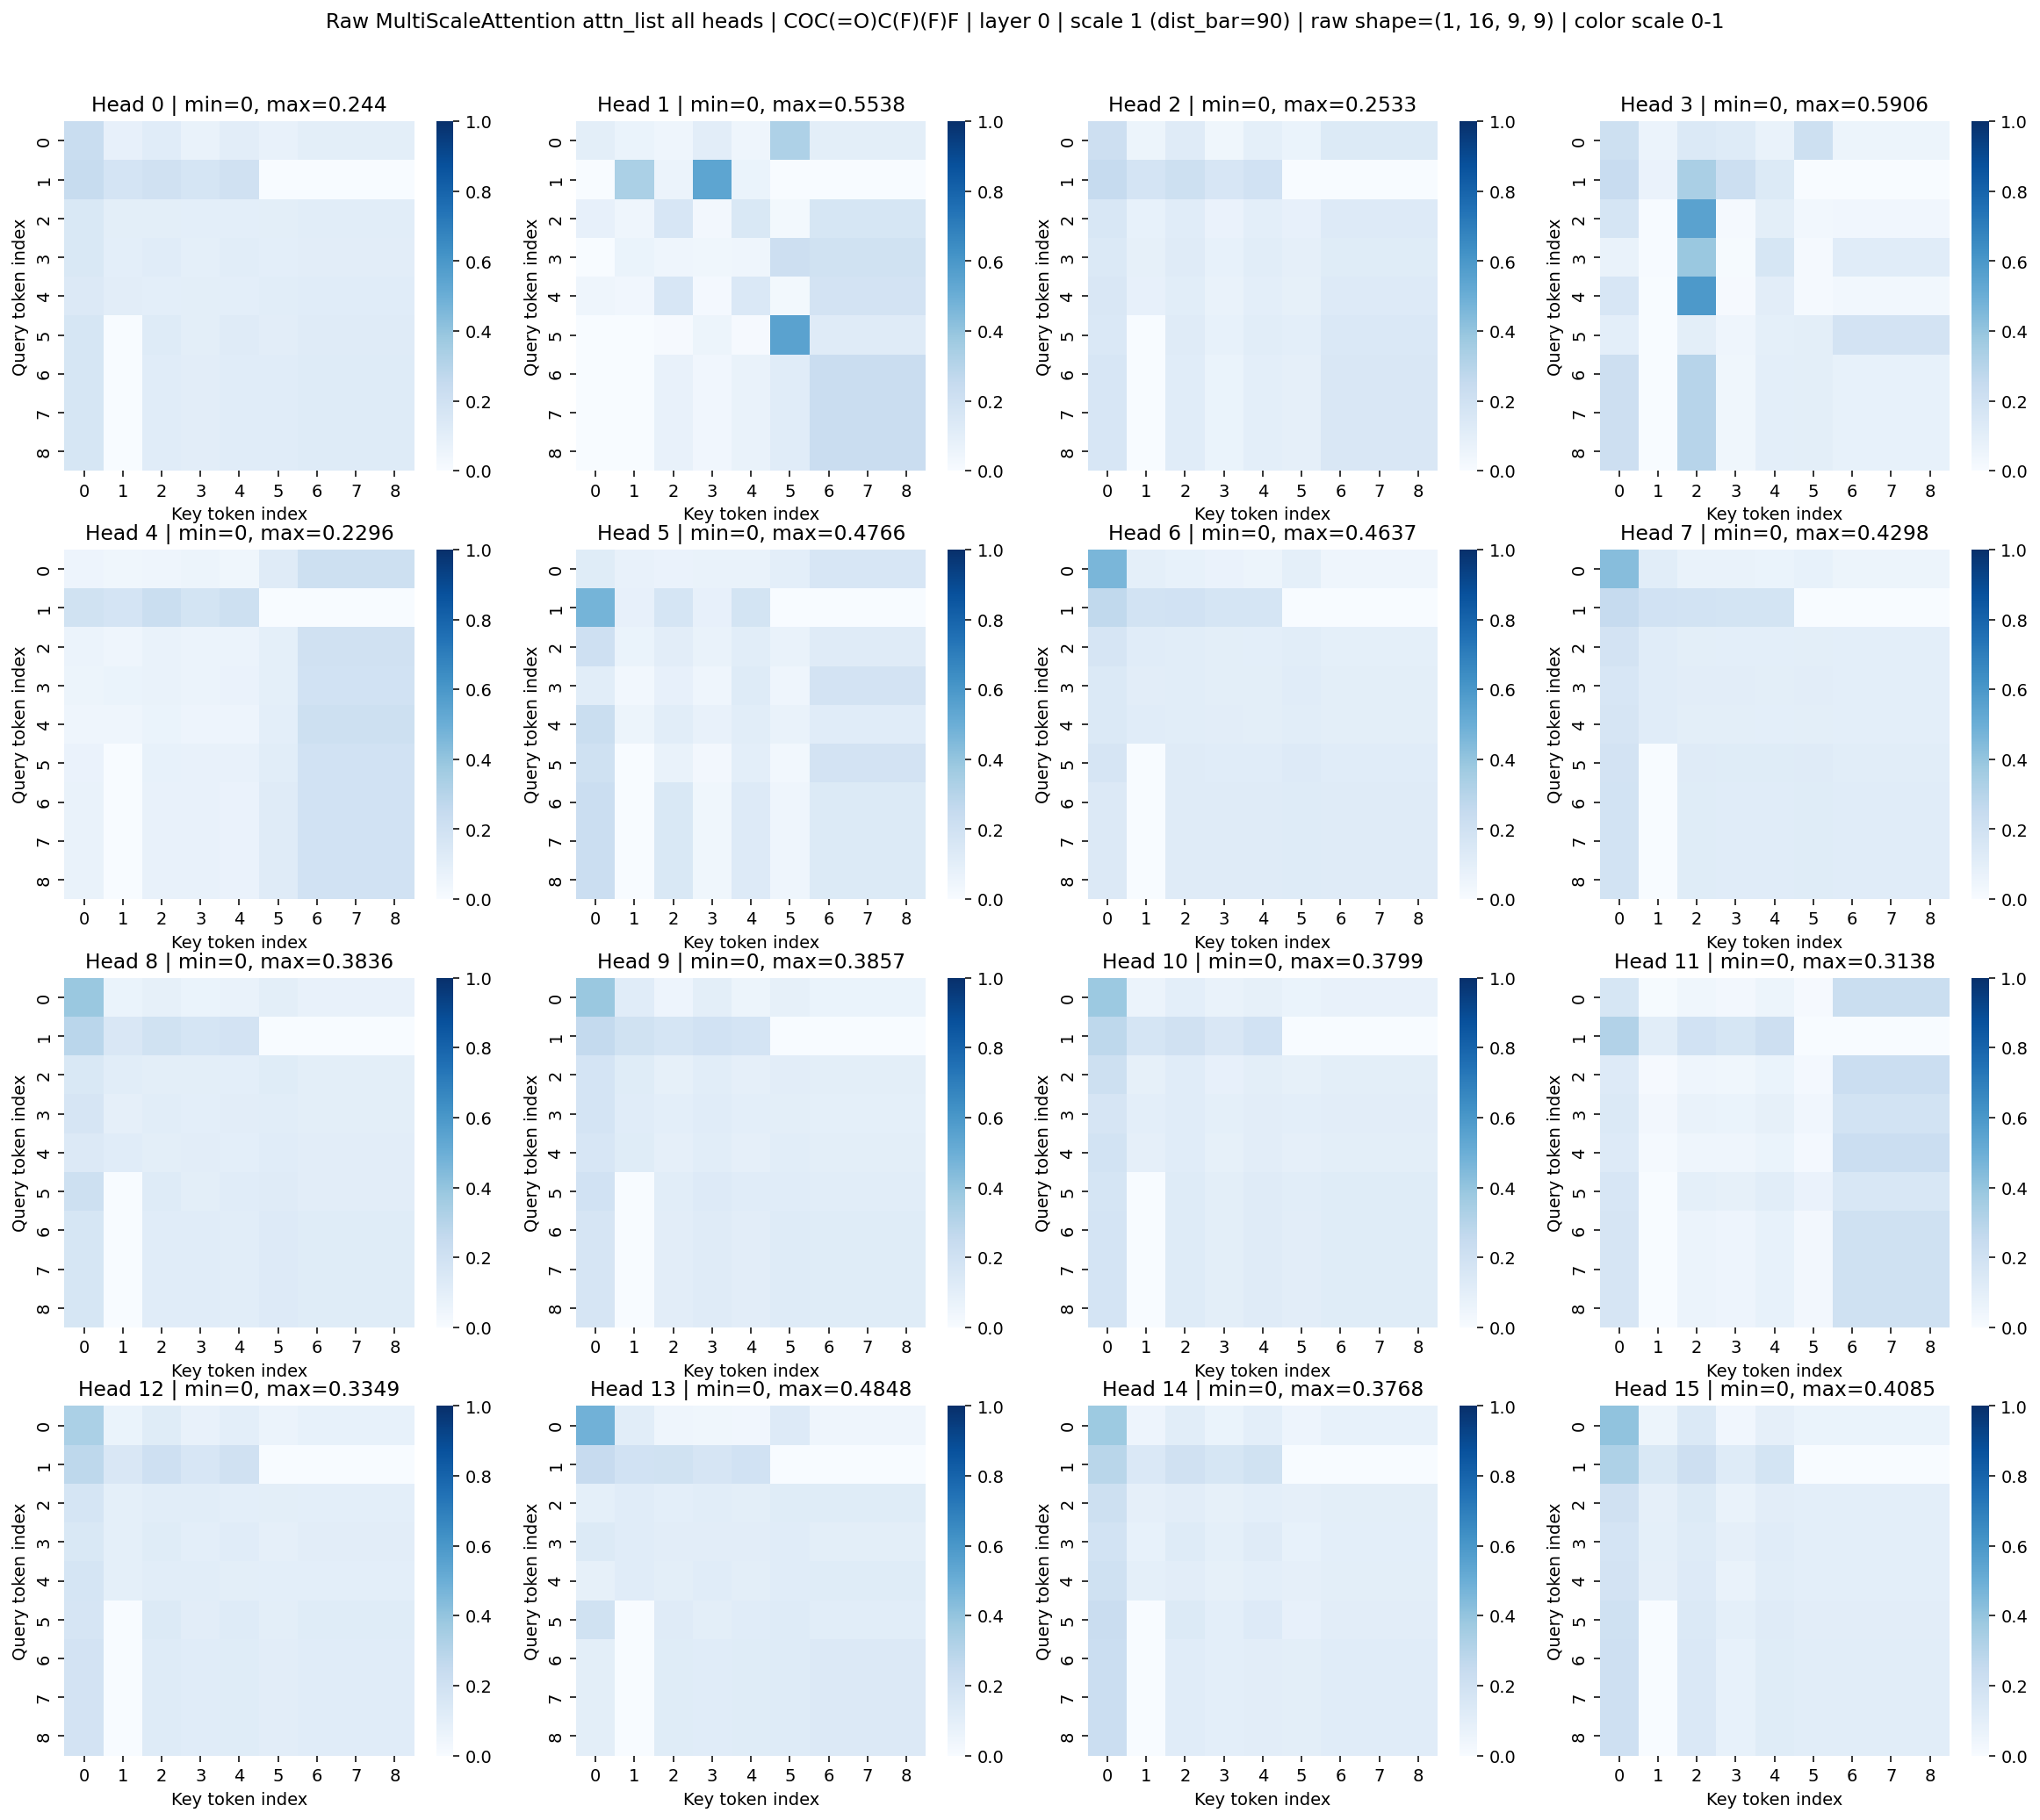

raw all-head attn layer=0, scale=1, dist_bar=90, shape=(1, 16, 9, 9), min=0, max=0.590554


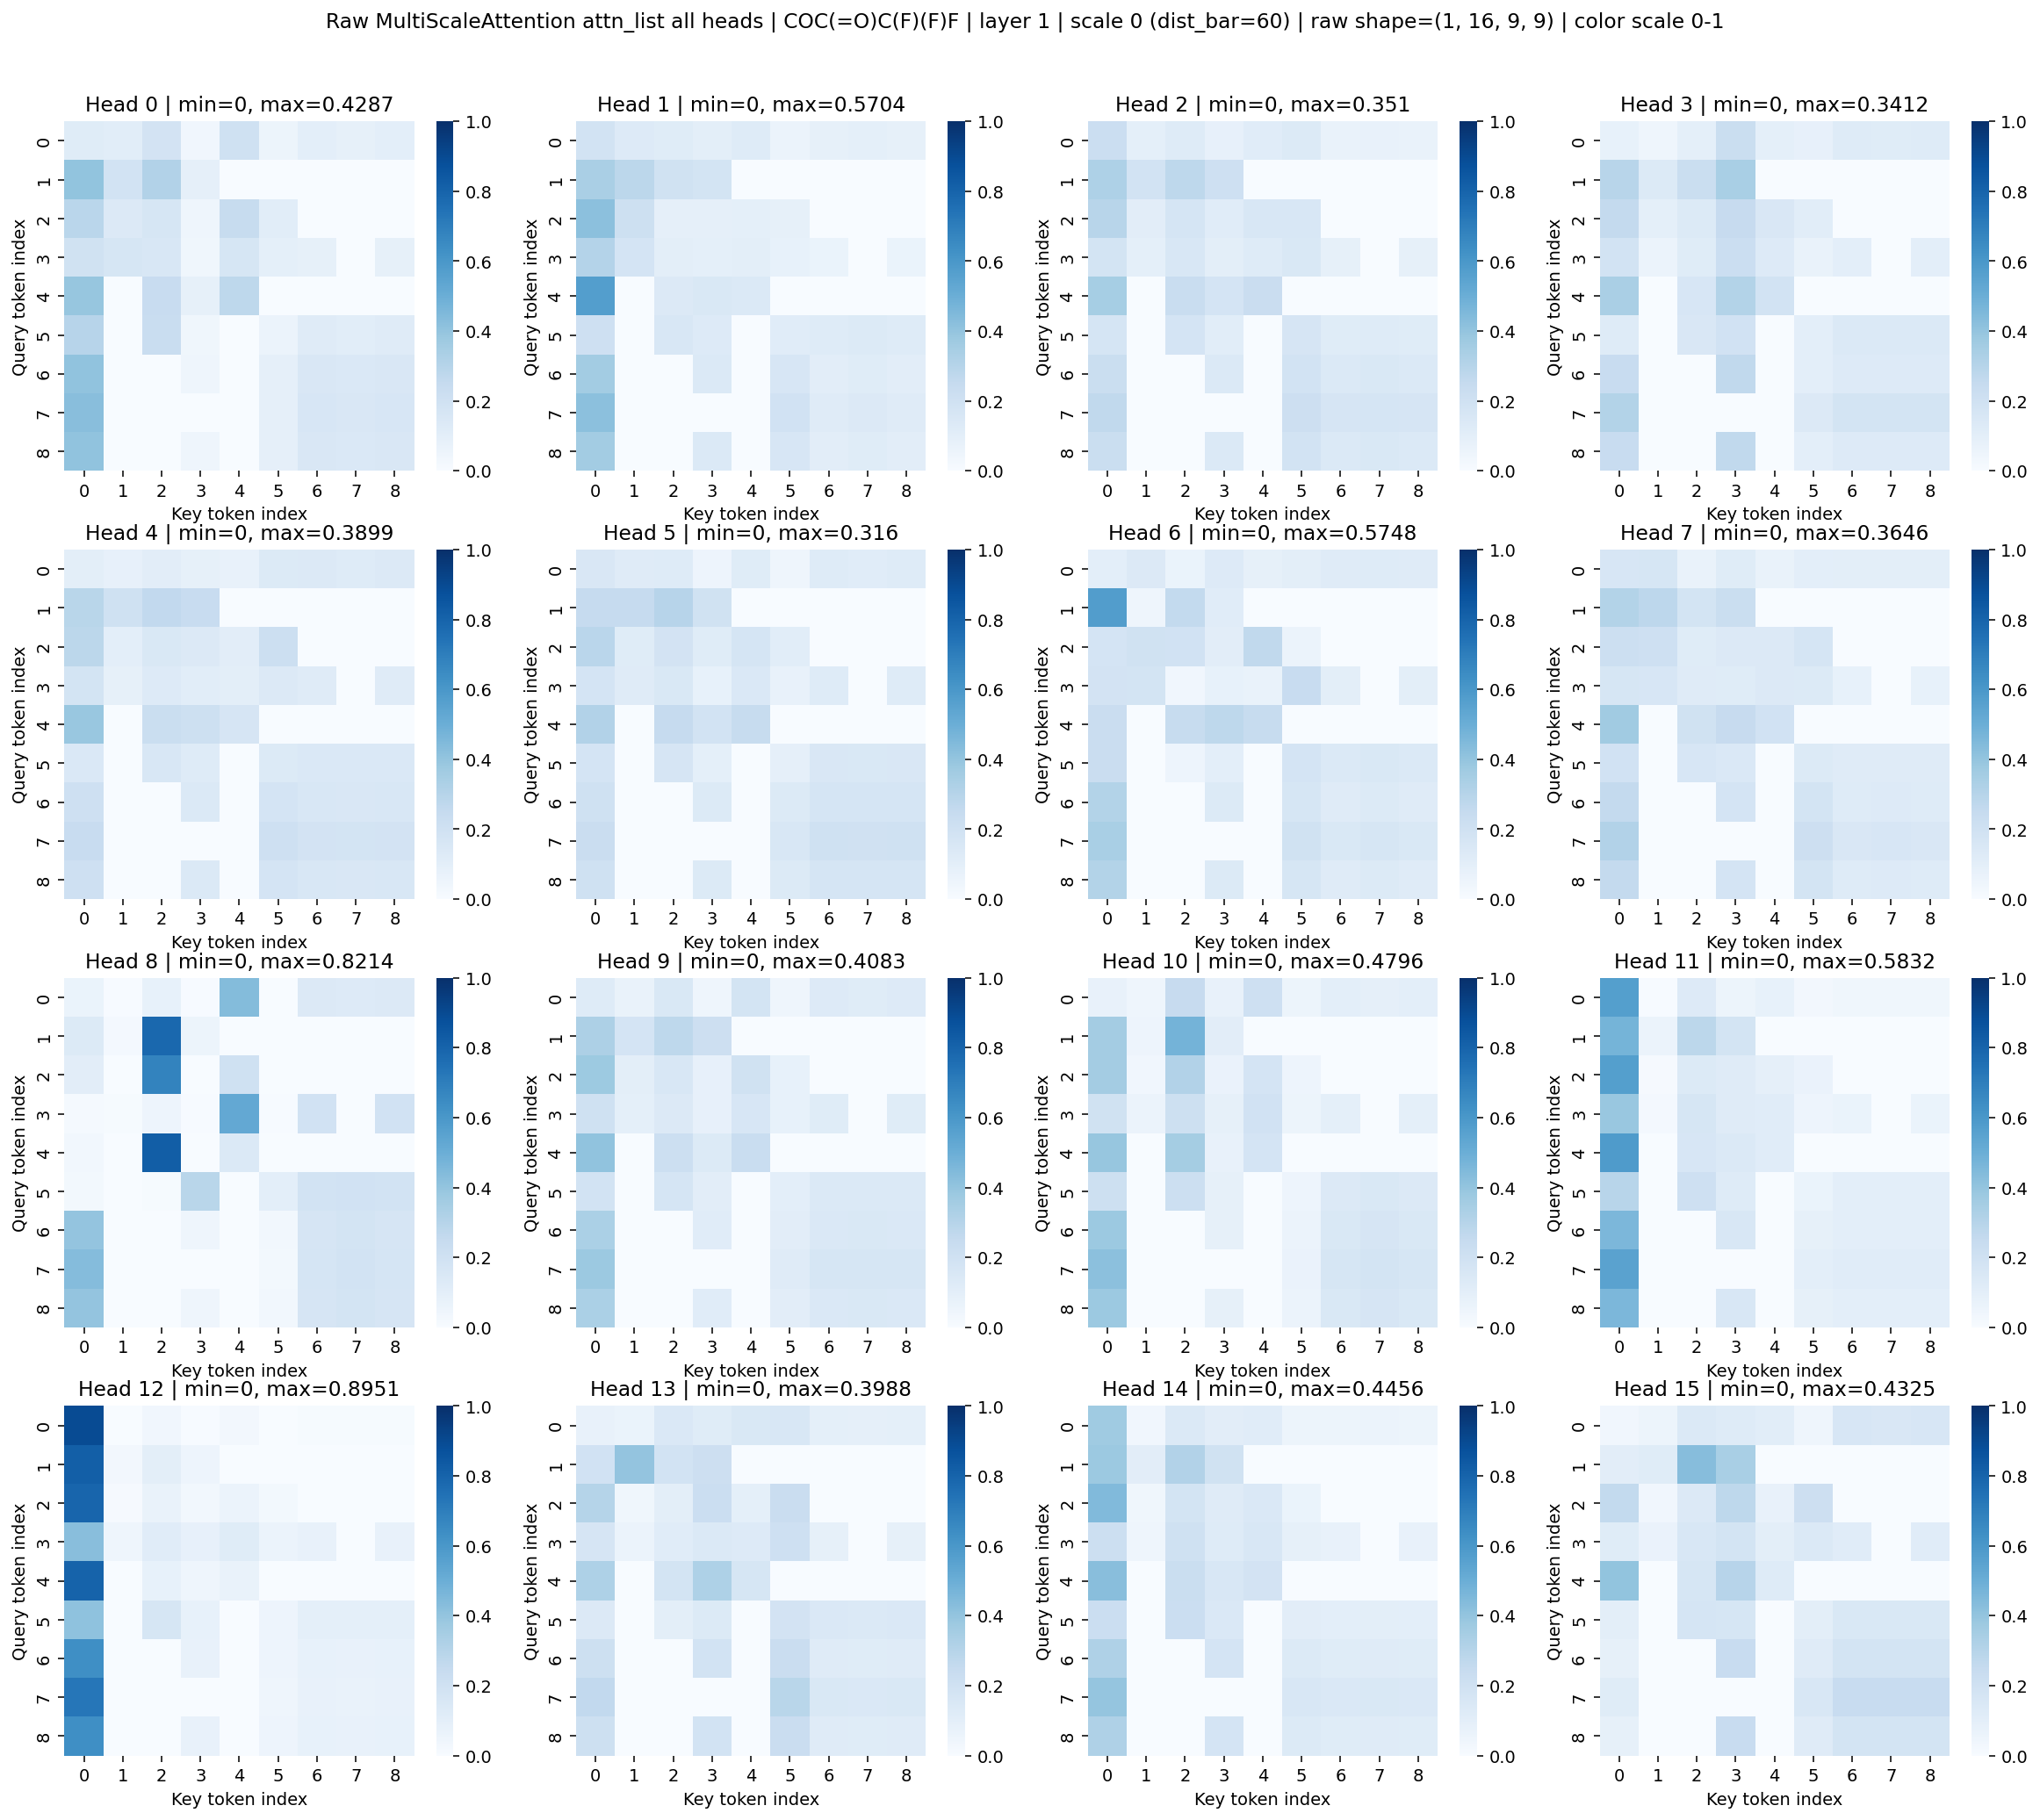

raw all-head attn layer=1, scale=0, dist_bar=60, shape=(1, 16, 9, 9), min=0, max=0.8951


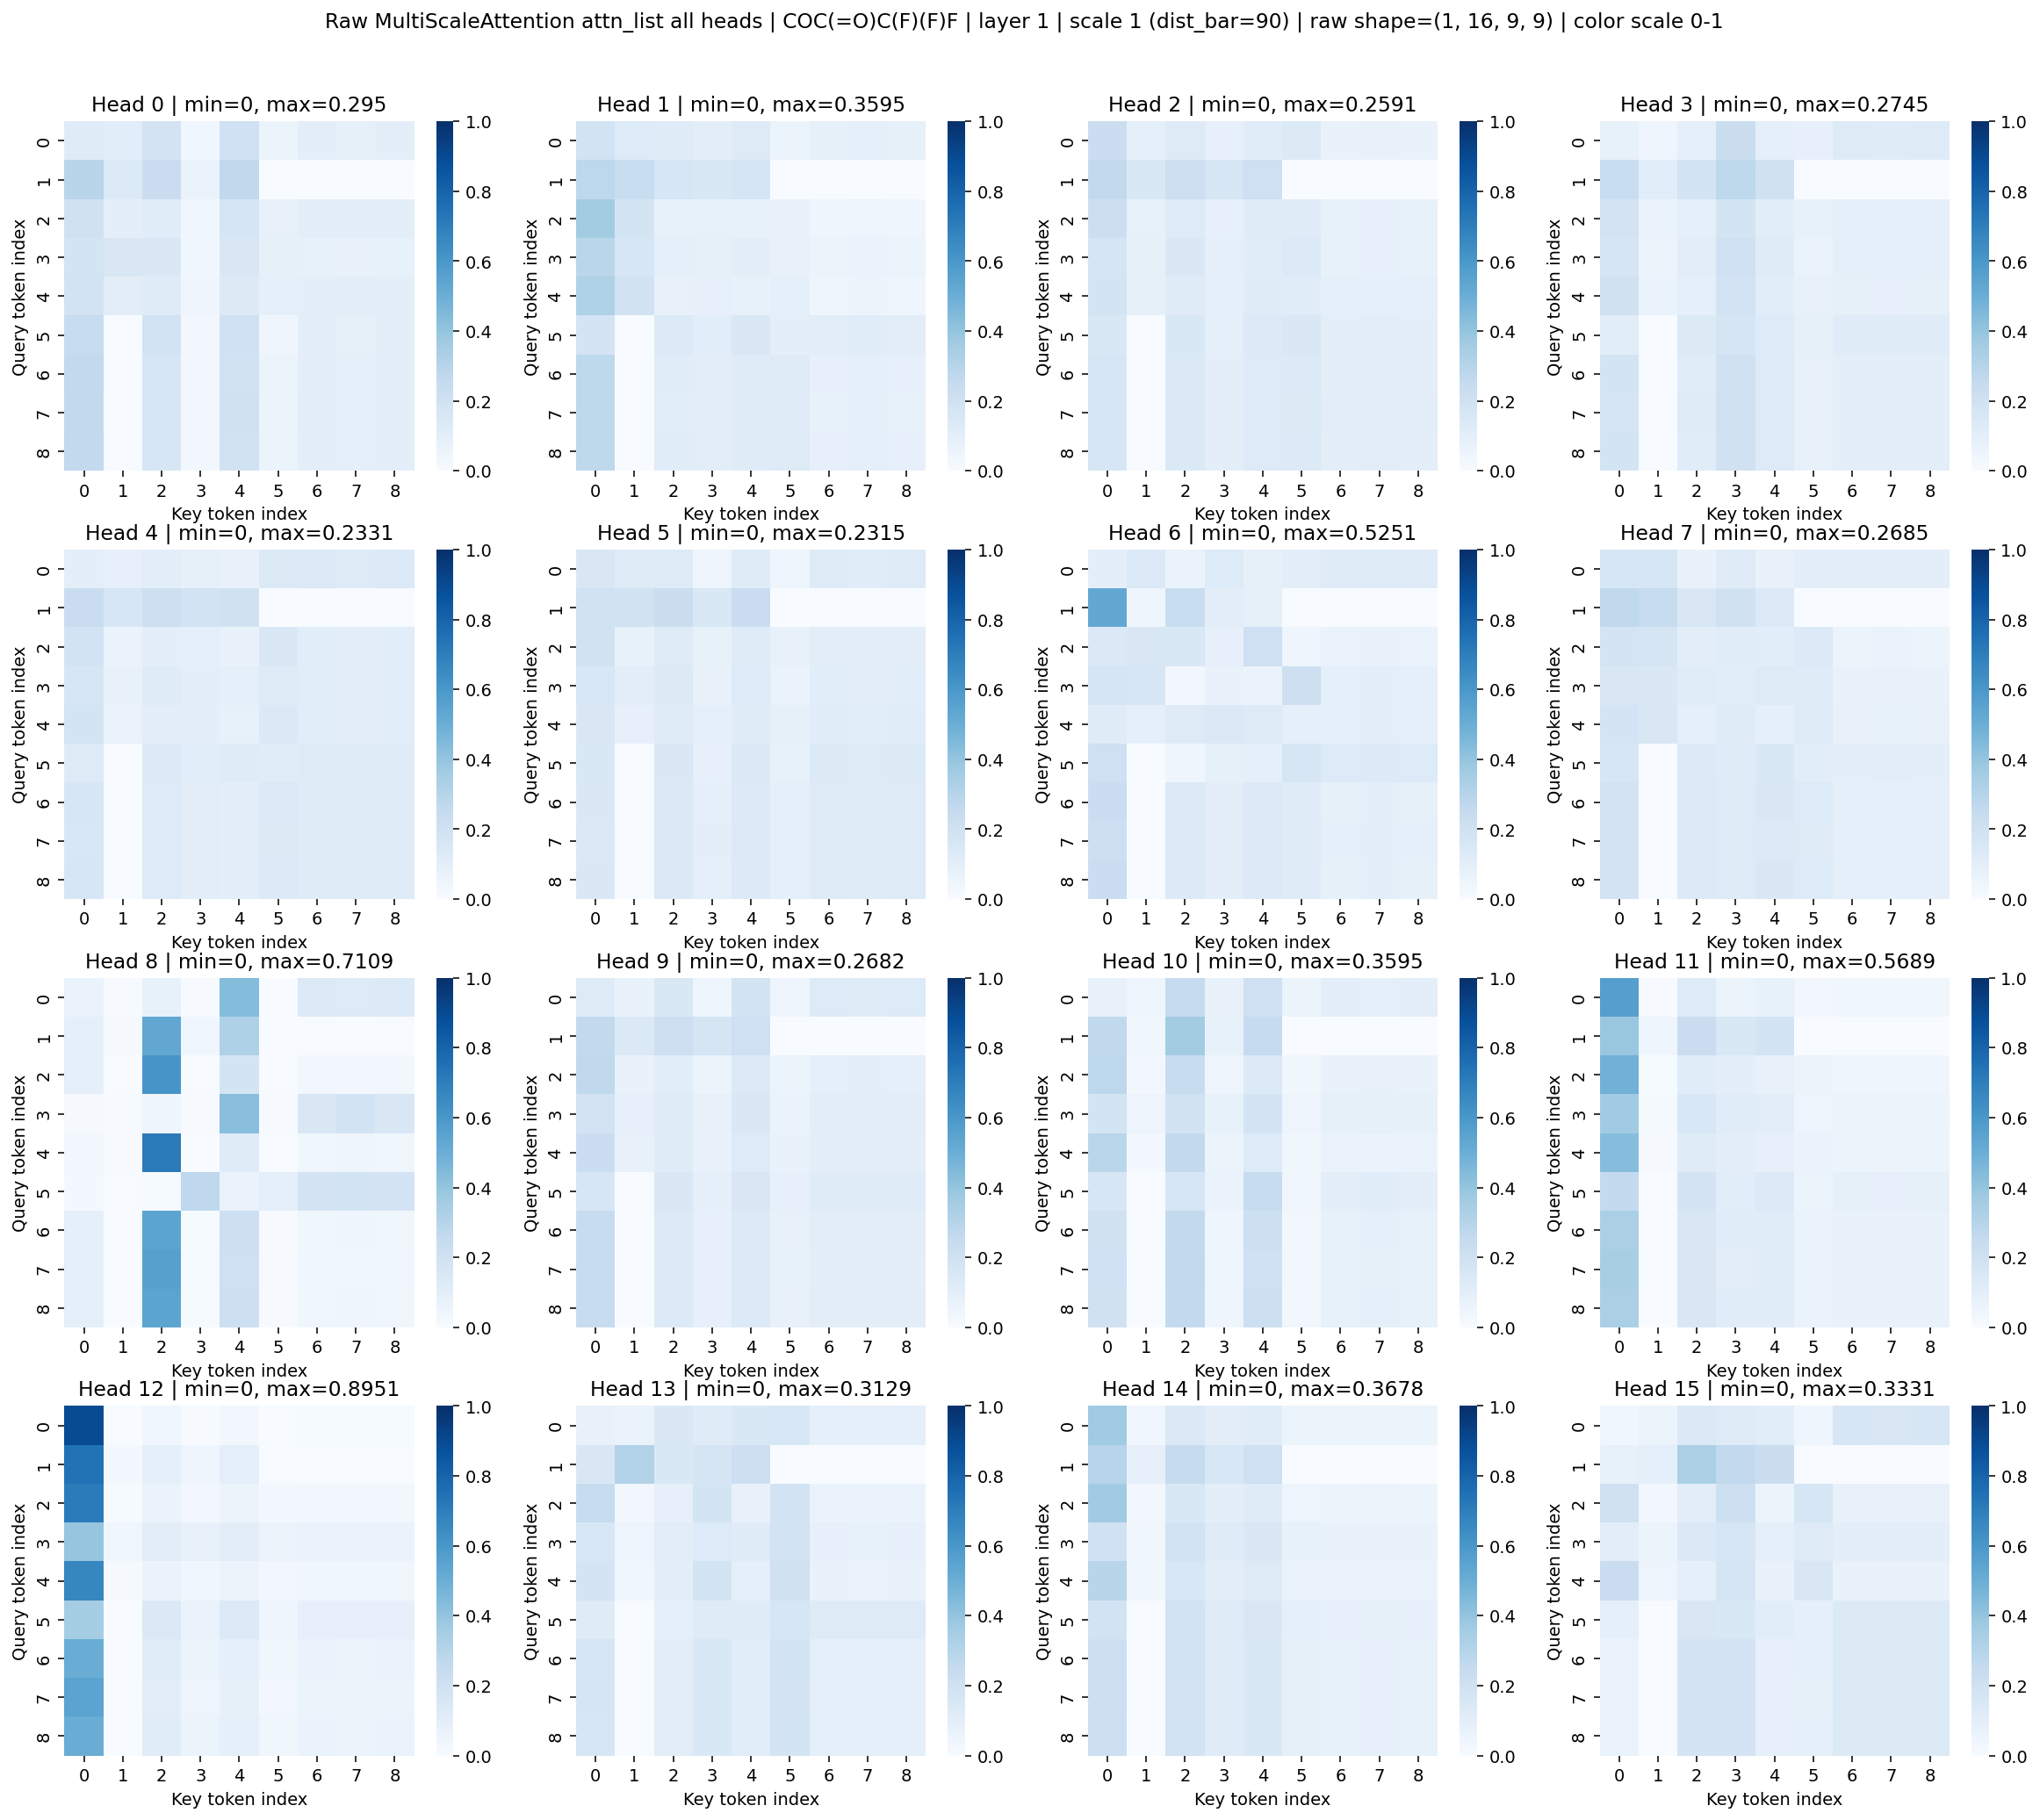

raw all-head attn layer=1, scale=1, dist_bar=90, shape=(1, 16, 9, 9), min=0, max=0.8951


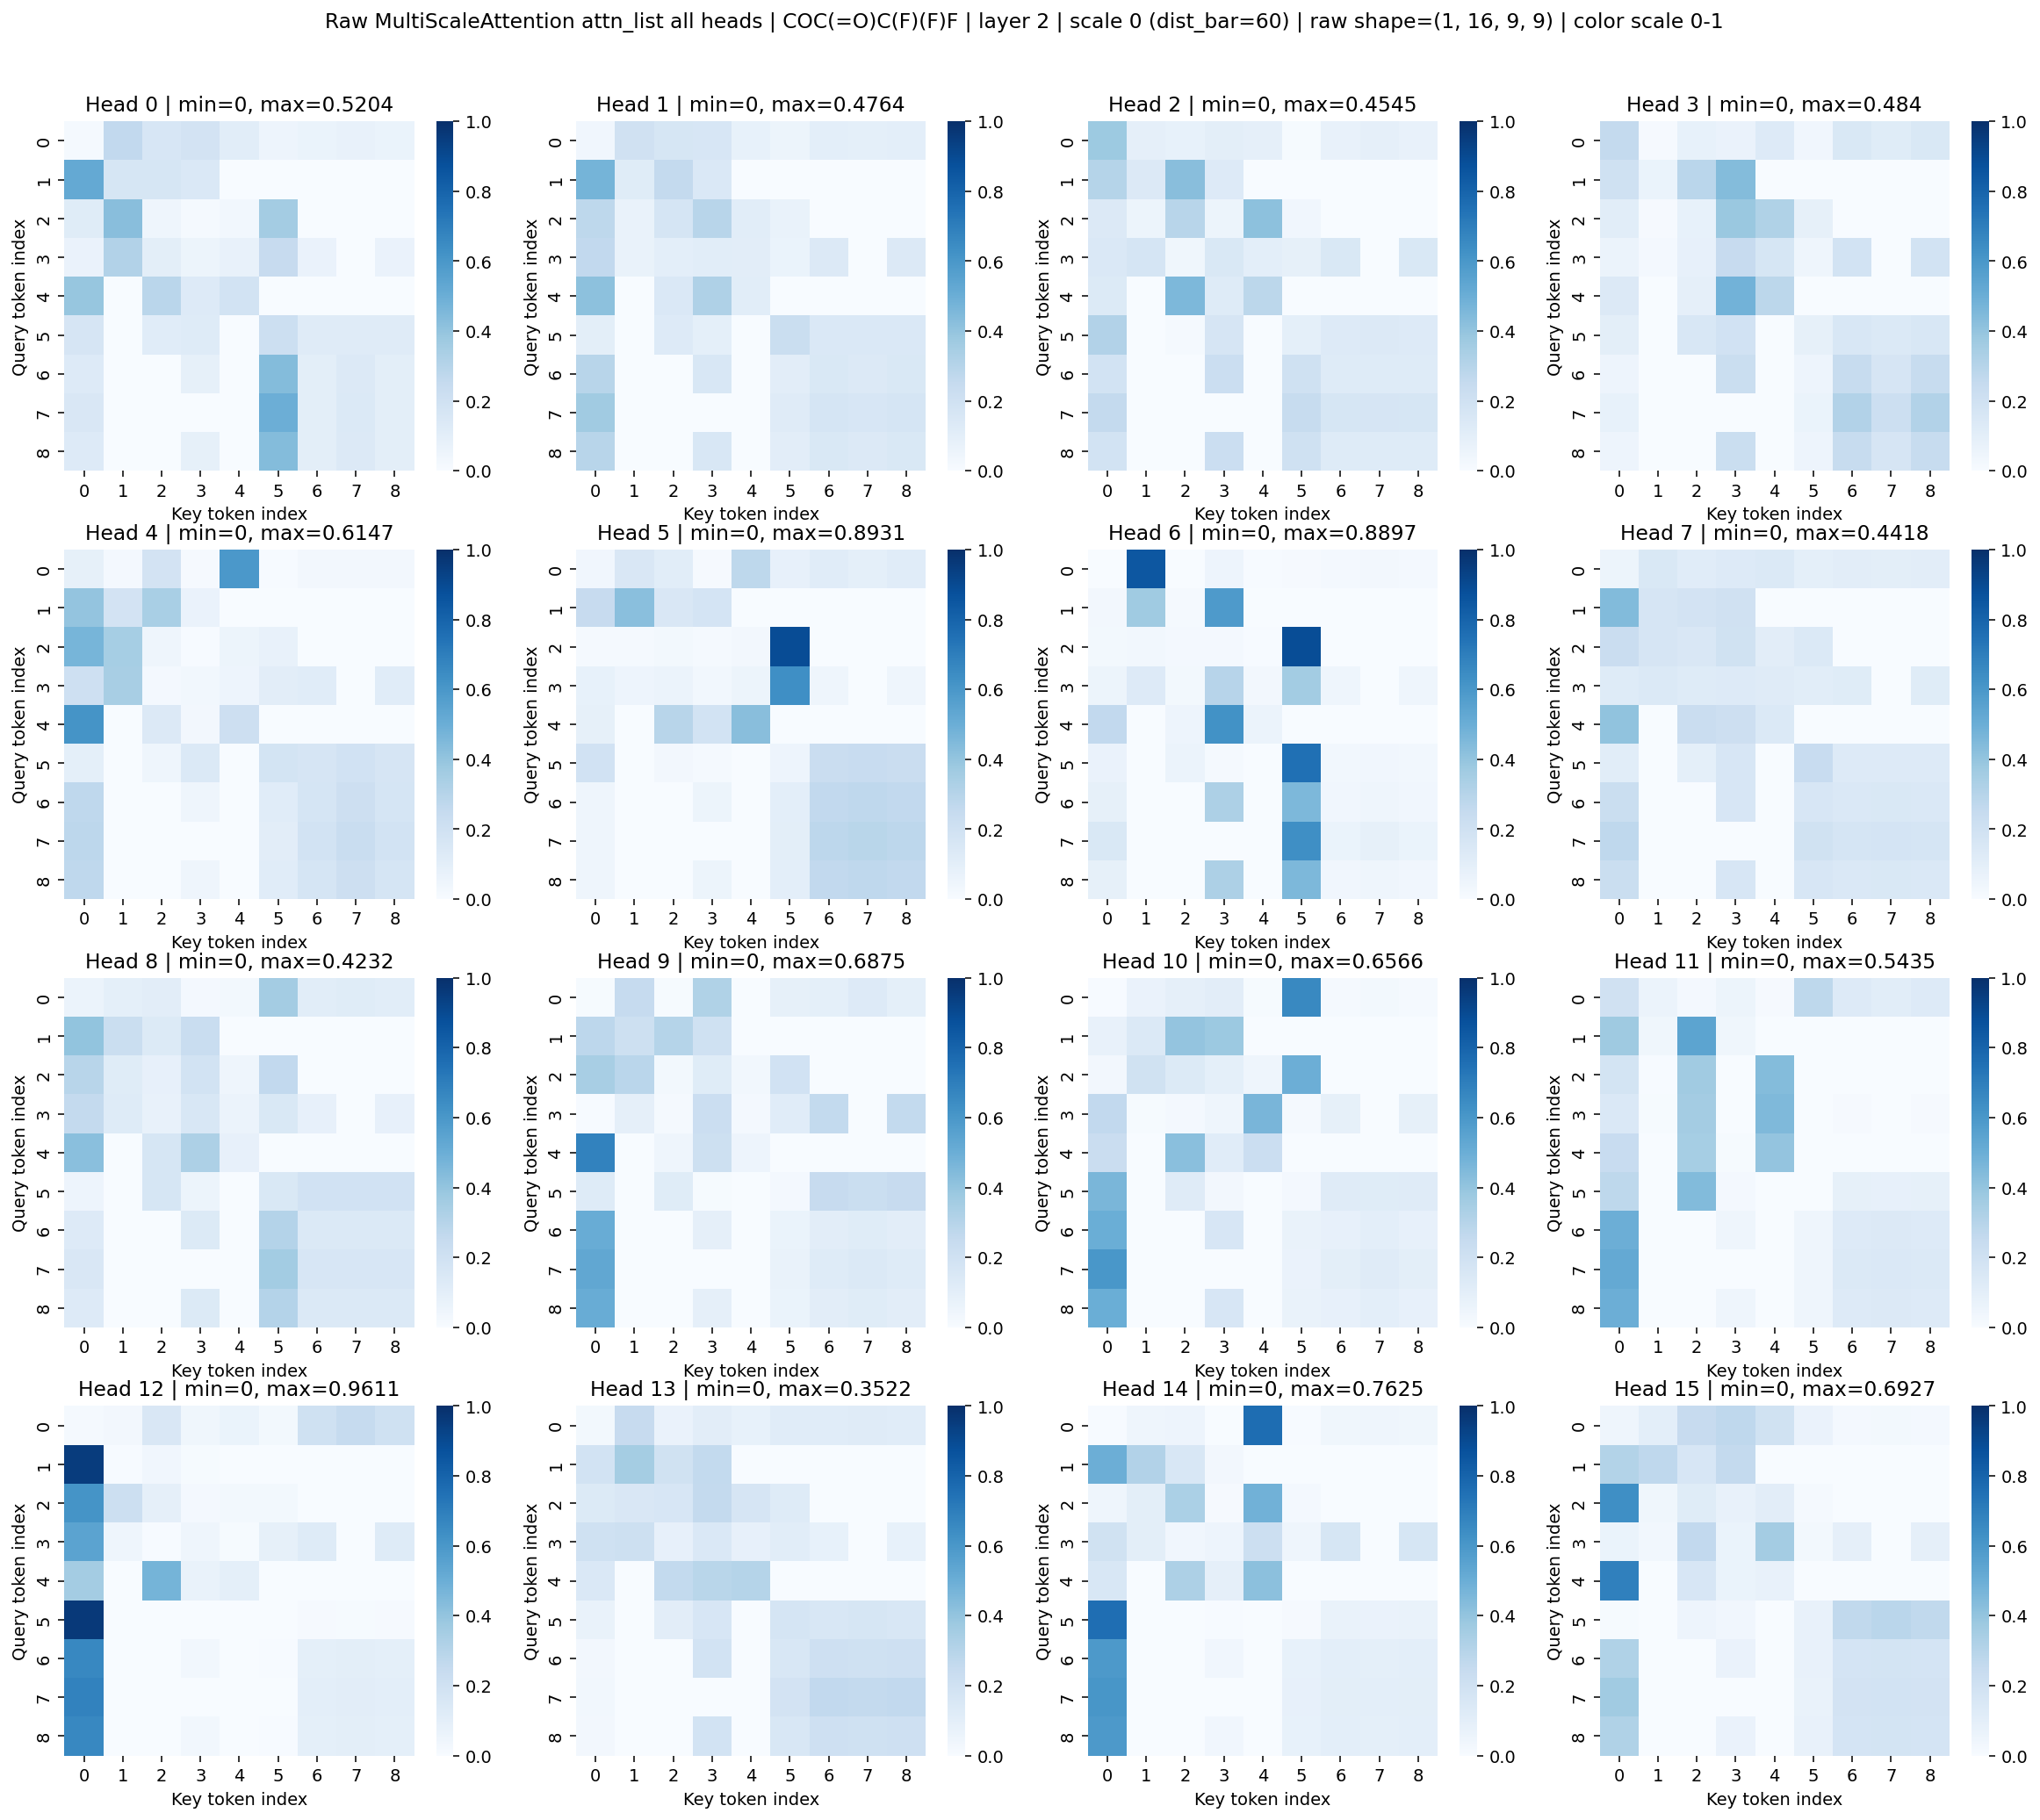

raw all-head attn layer=2, scale=0, dist_bar=60, shape=(1, 16, 9, 9), min=0, max=0.961139


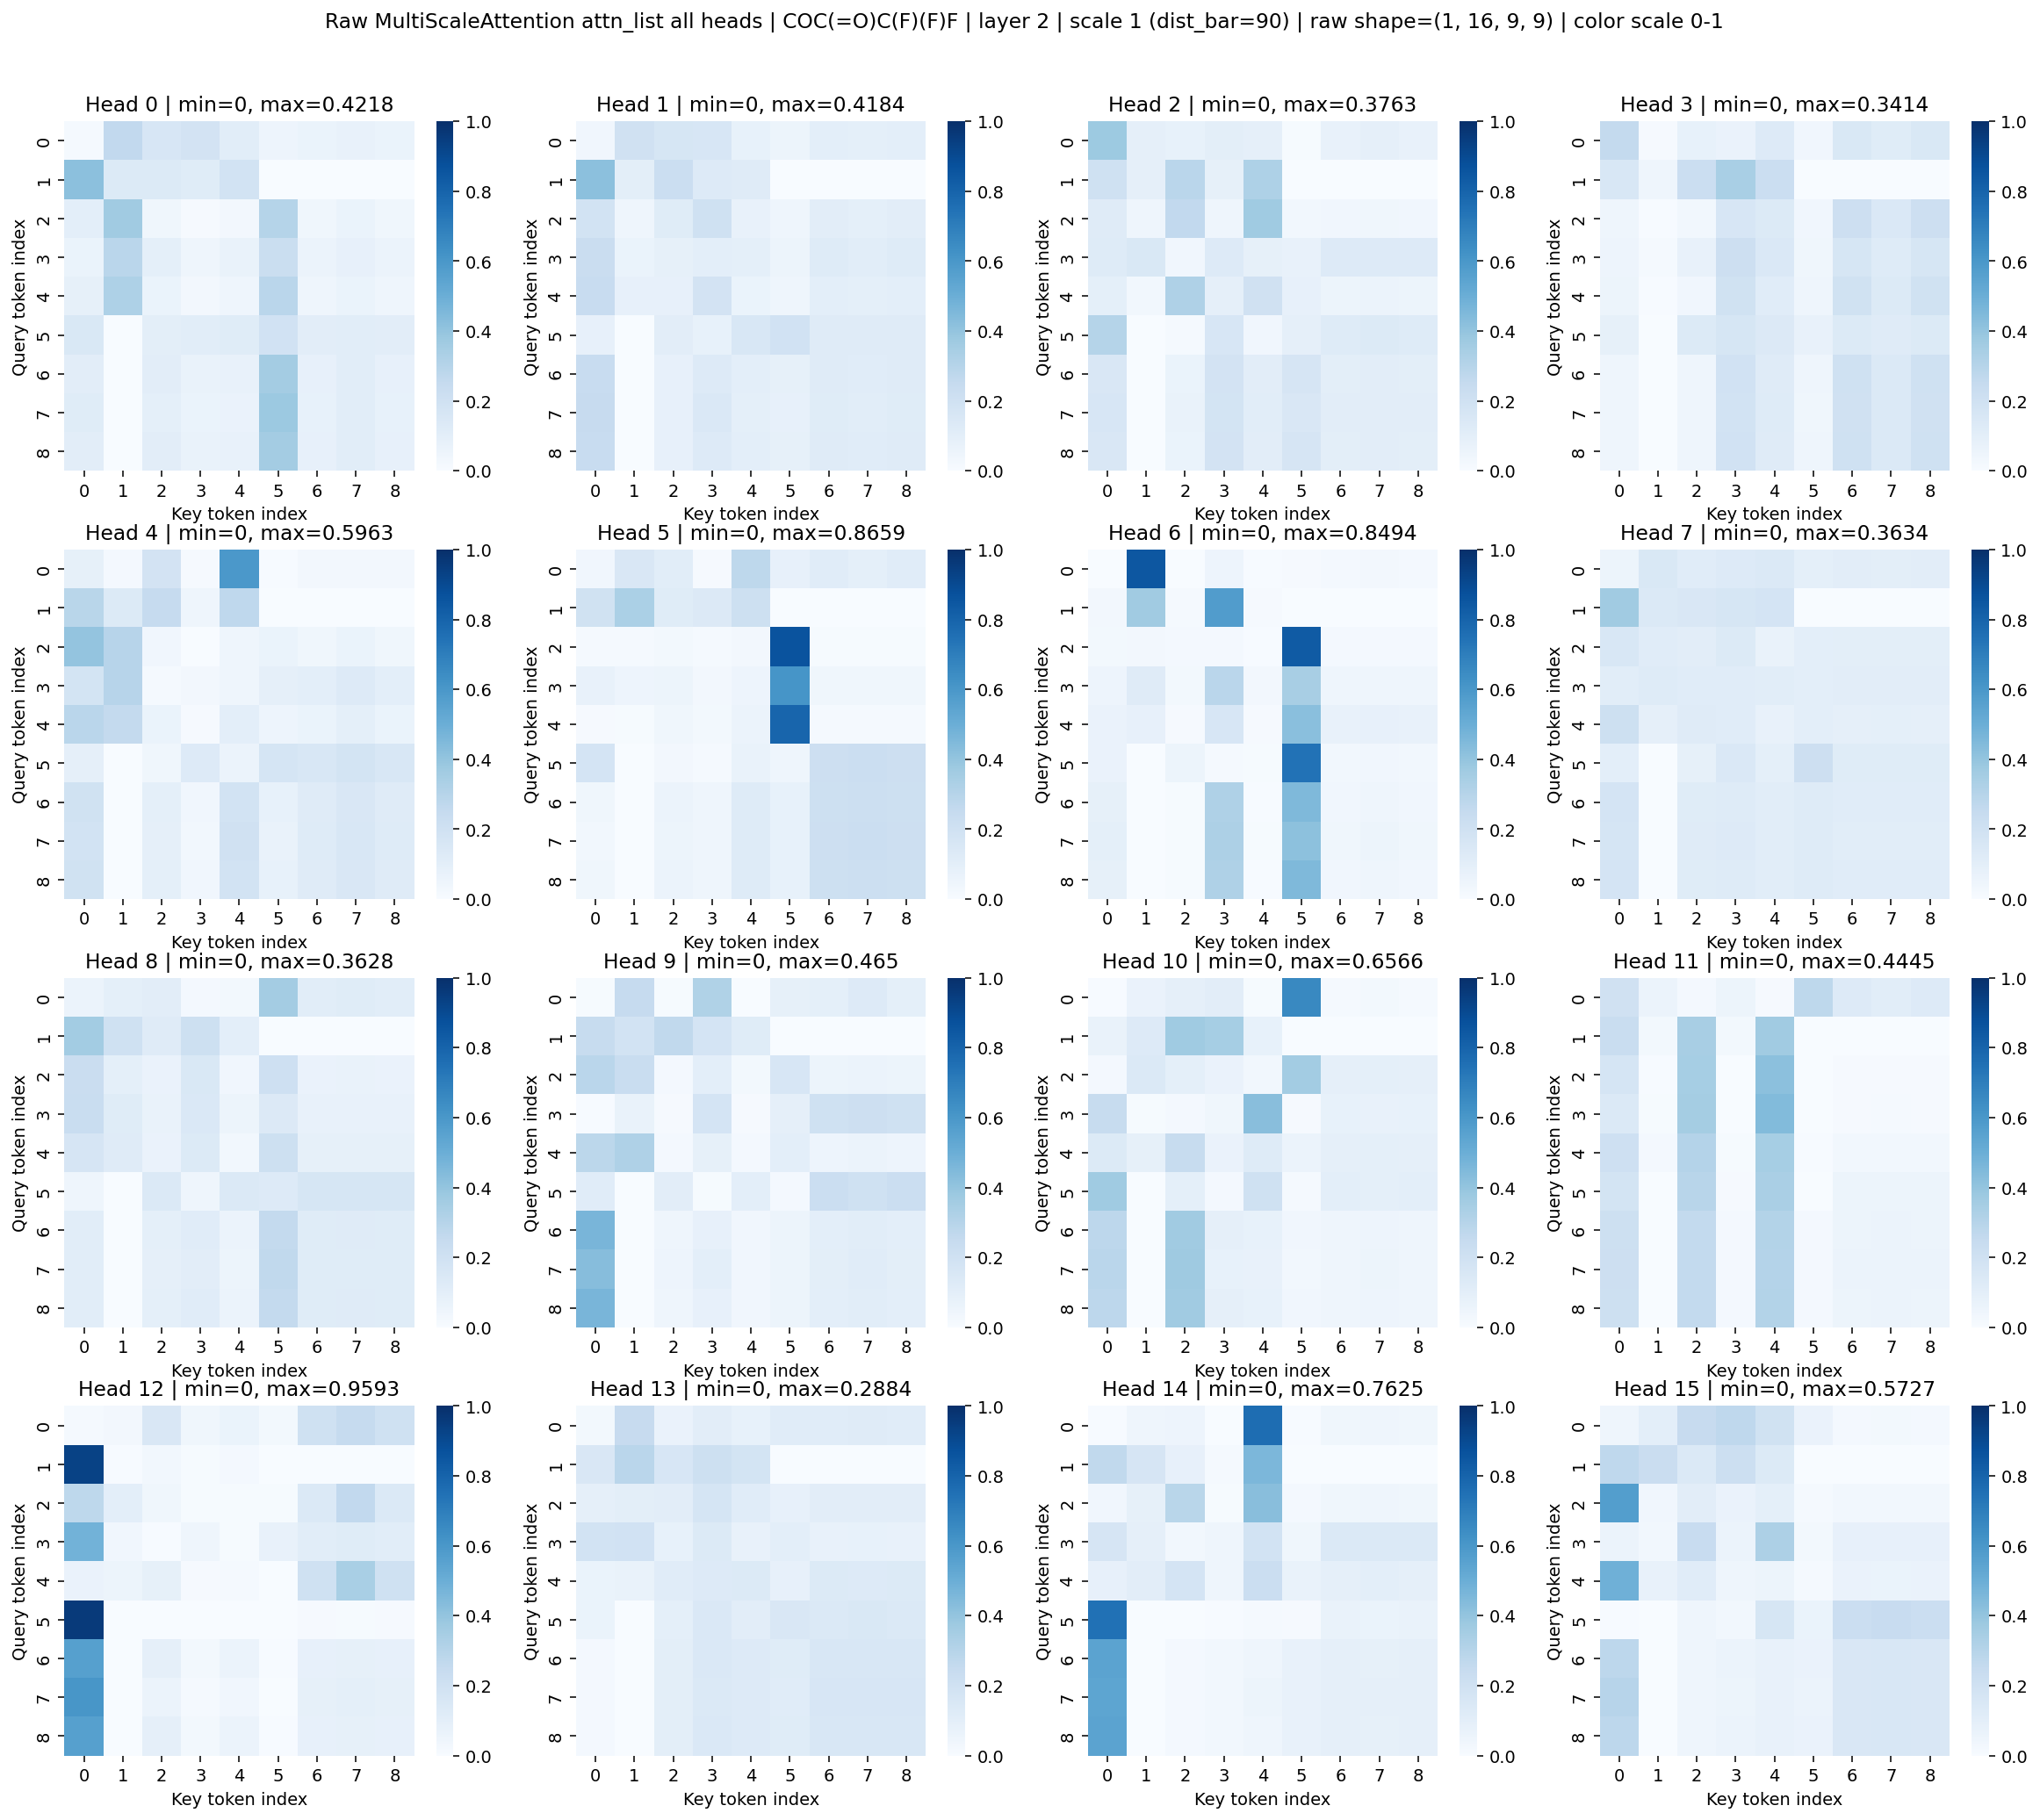

raw all-head attn layer=2, scale=1, dist_bar=90, shape=(1, 16, 9, 9), min=0, max=0.959254


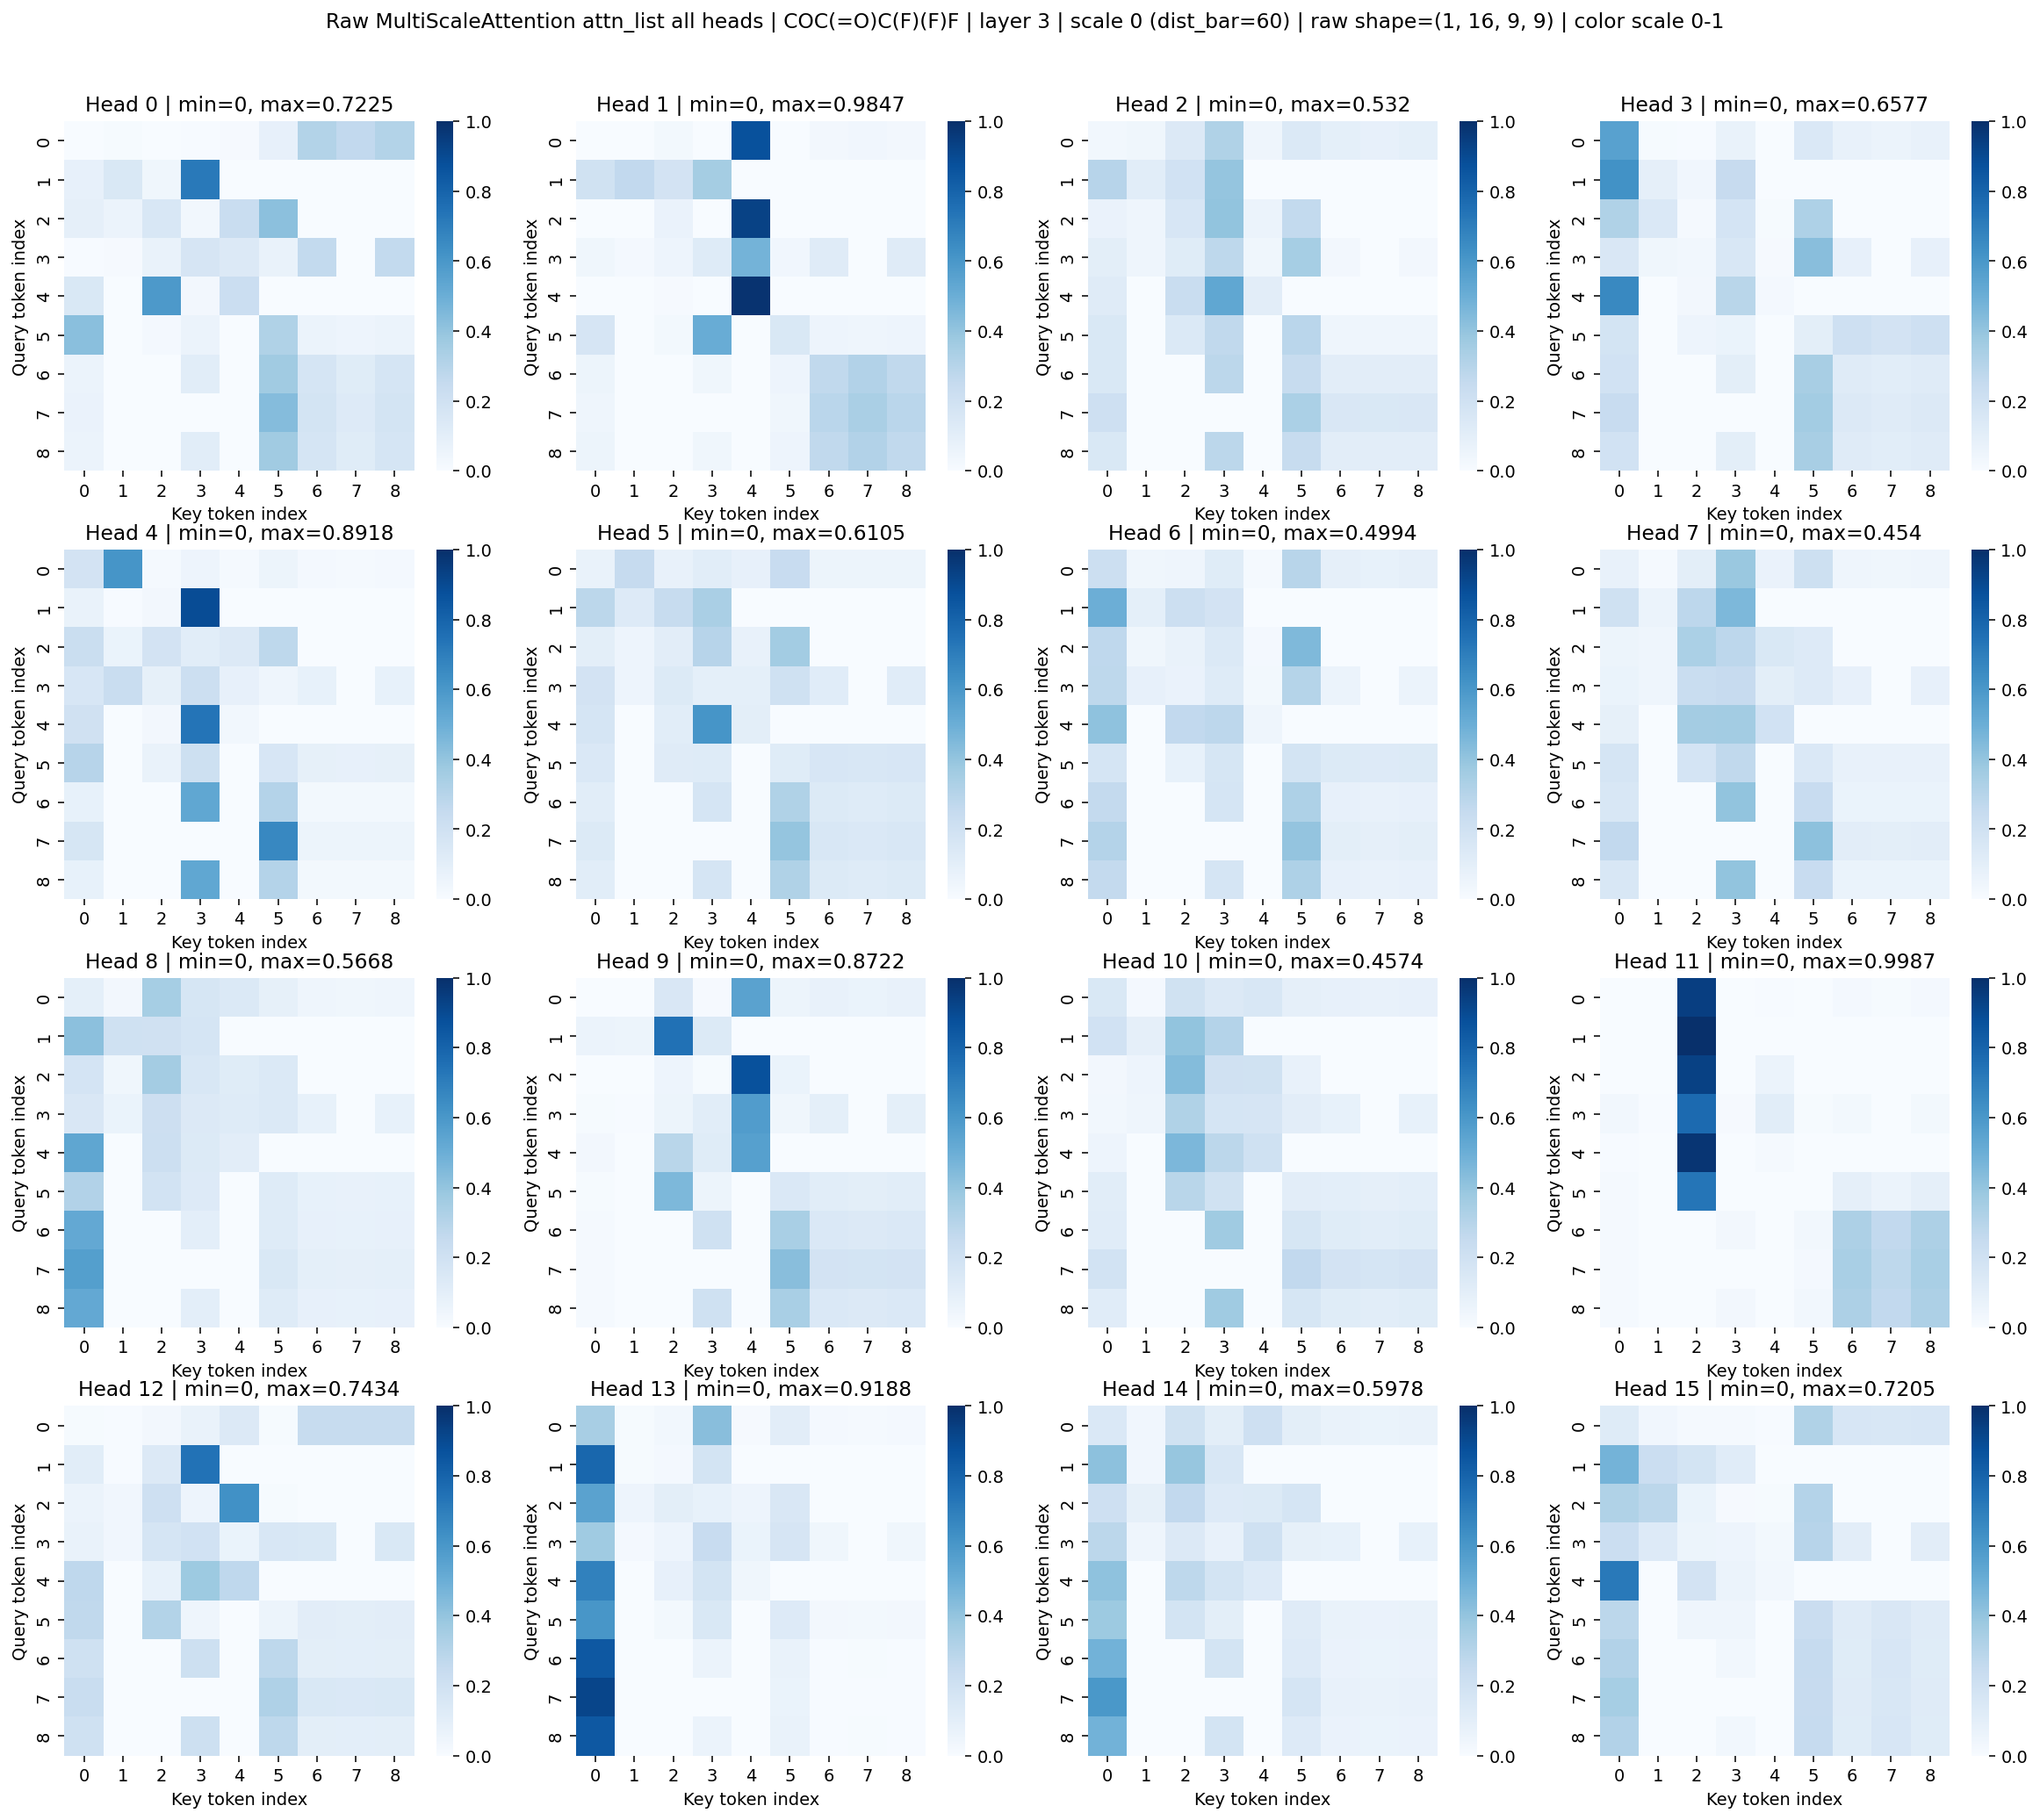

raw all-head attn layer=3, scale=0, dist_bar=60, shape=(1, 16, 9, 9), min=0, max=0.9987


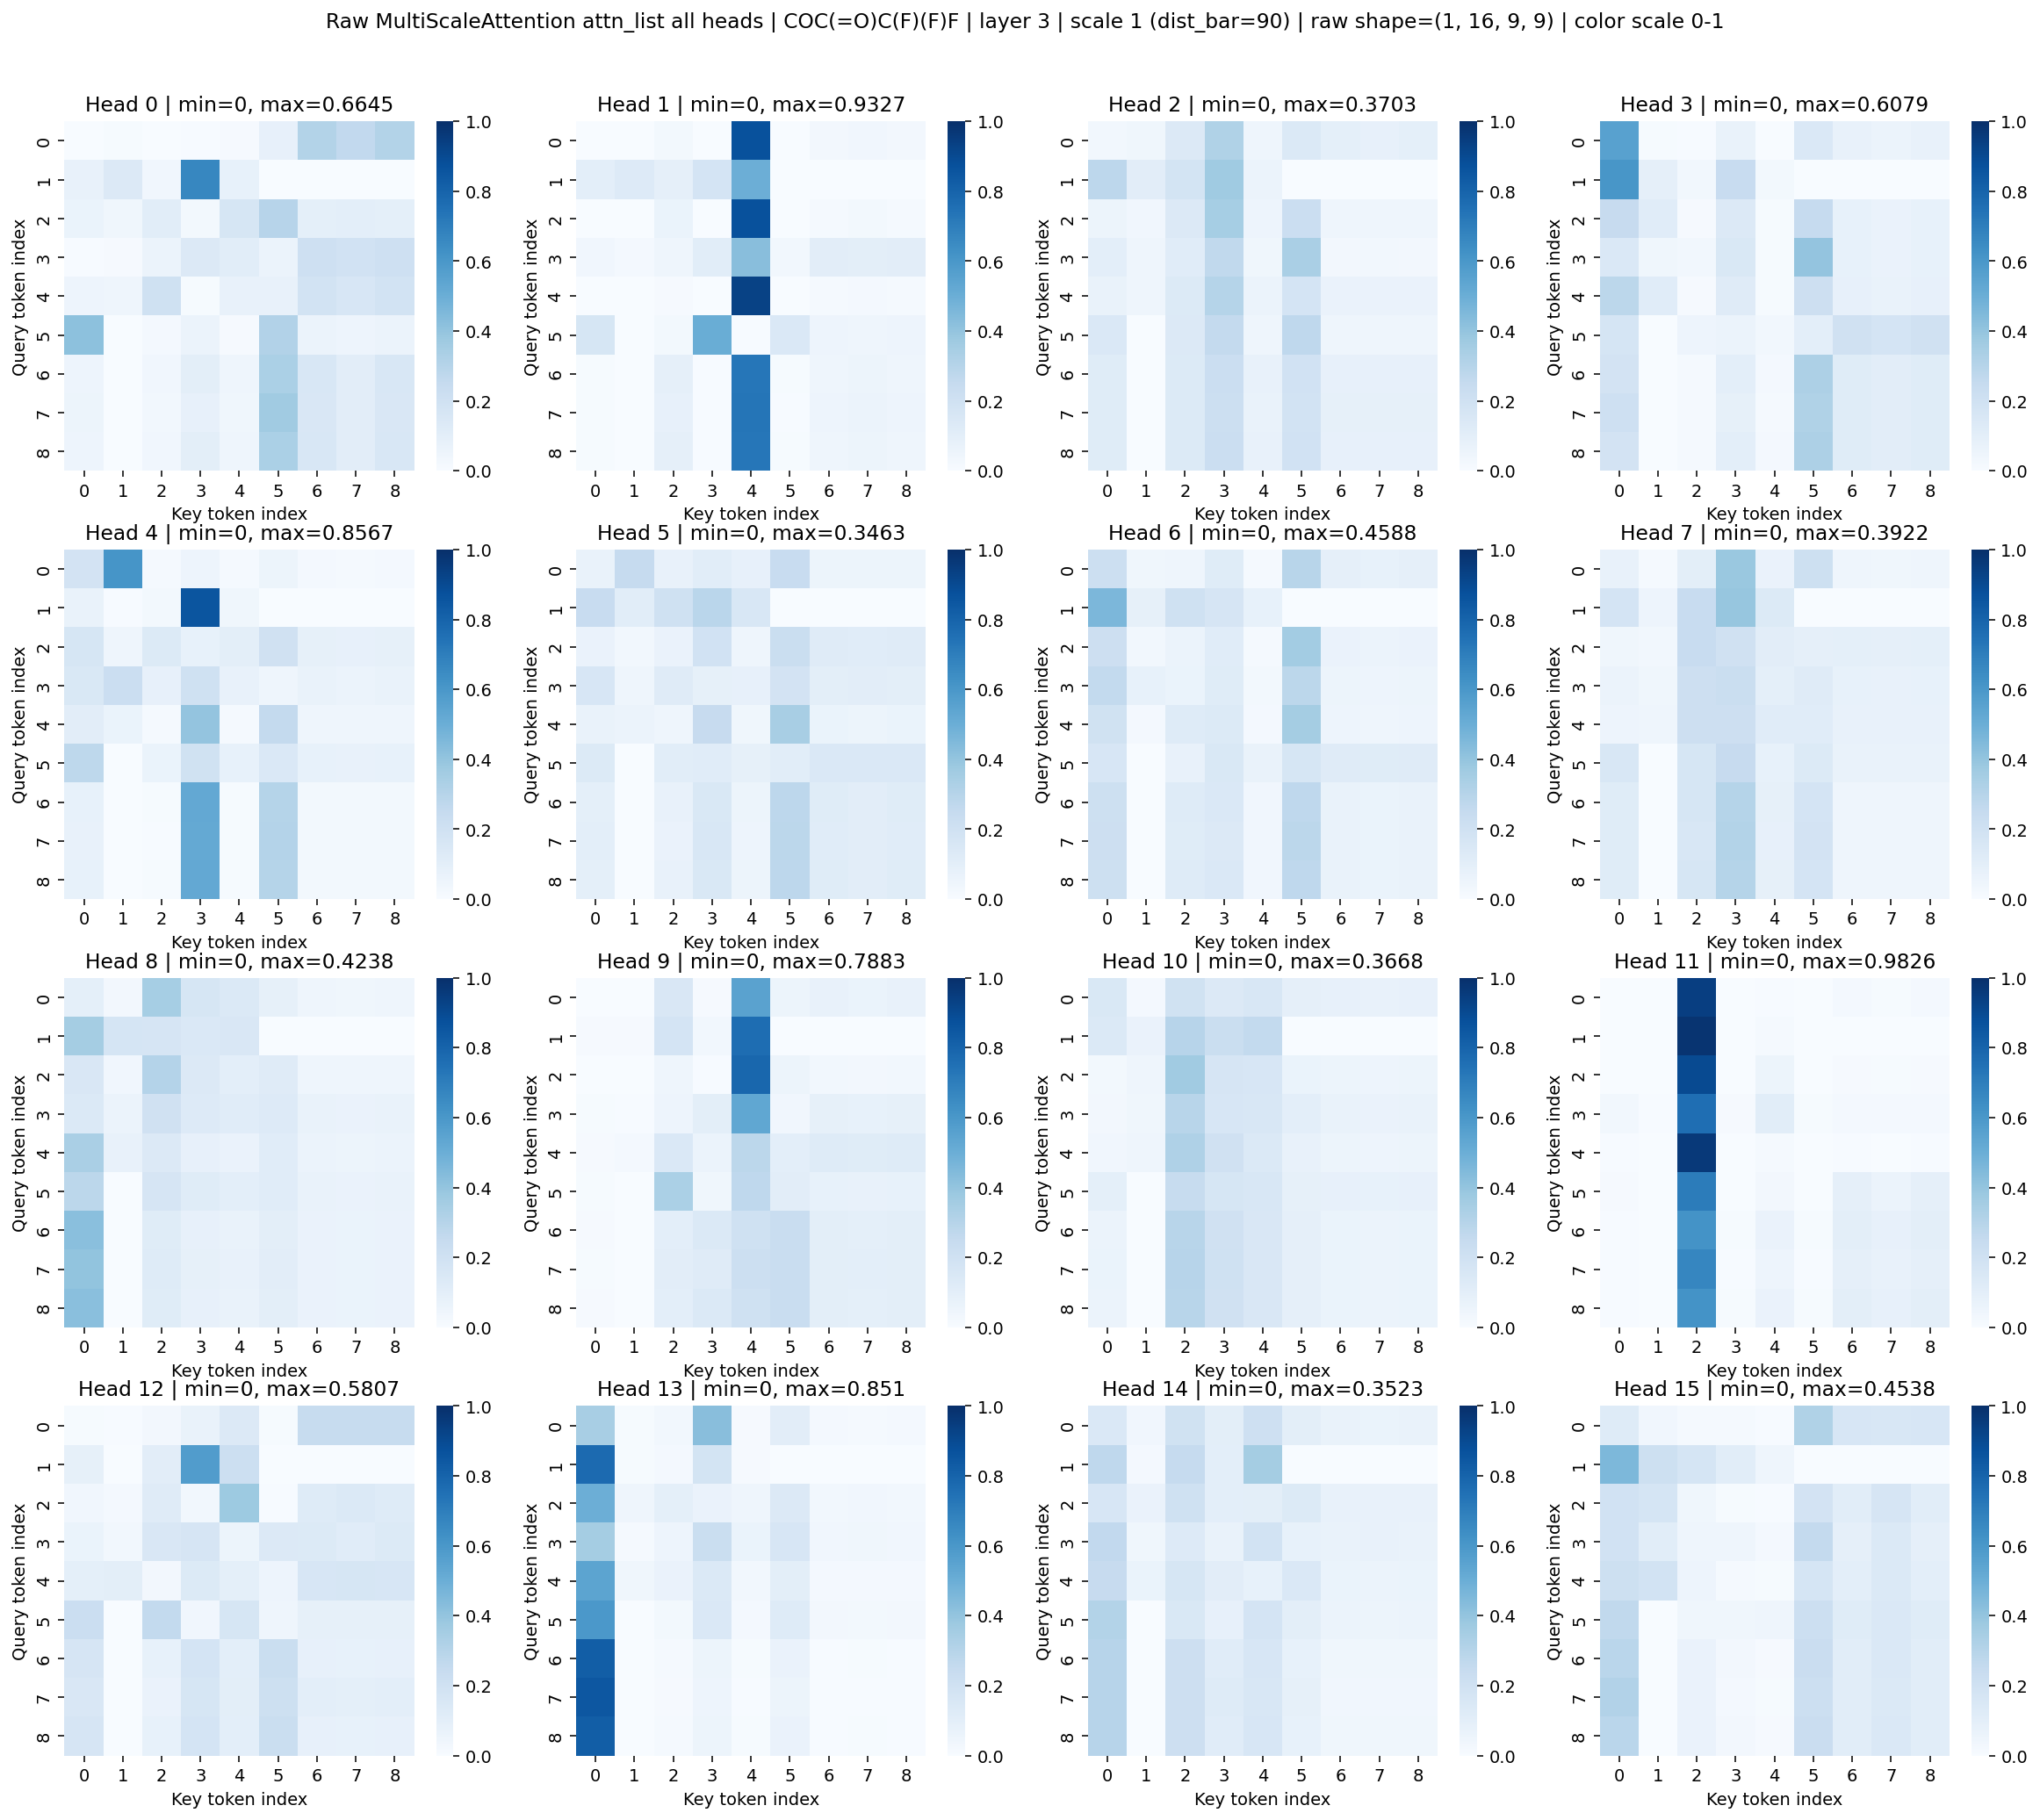

raw all-head attn layer=3, scale=1, dist_bar=90, shape=(1, 16, 9, 9), min=0, max=0.982567


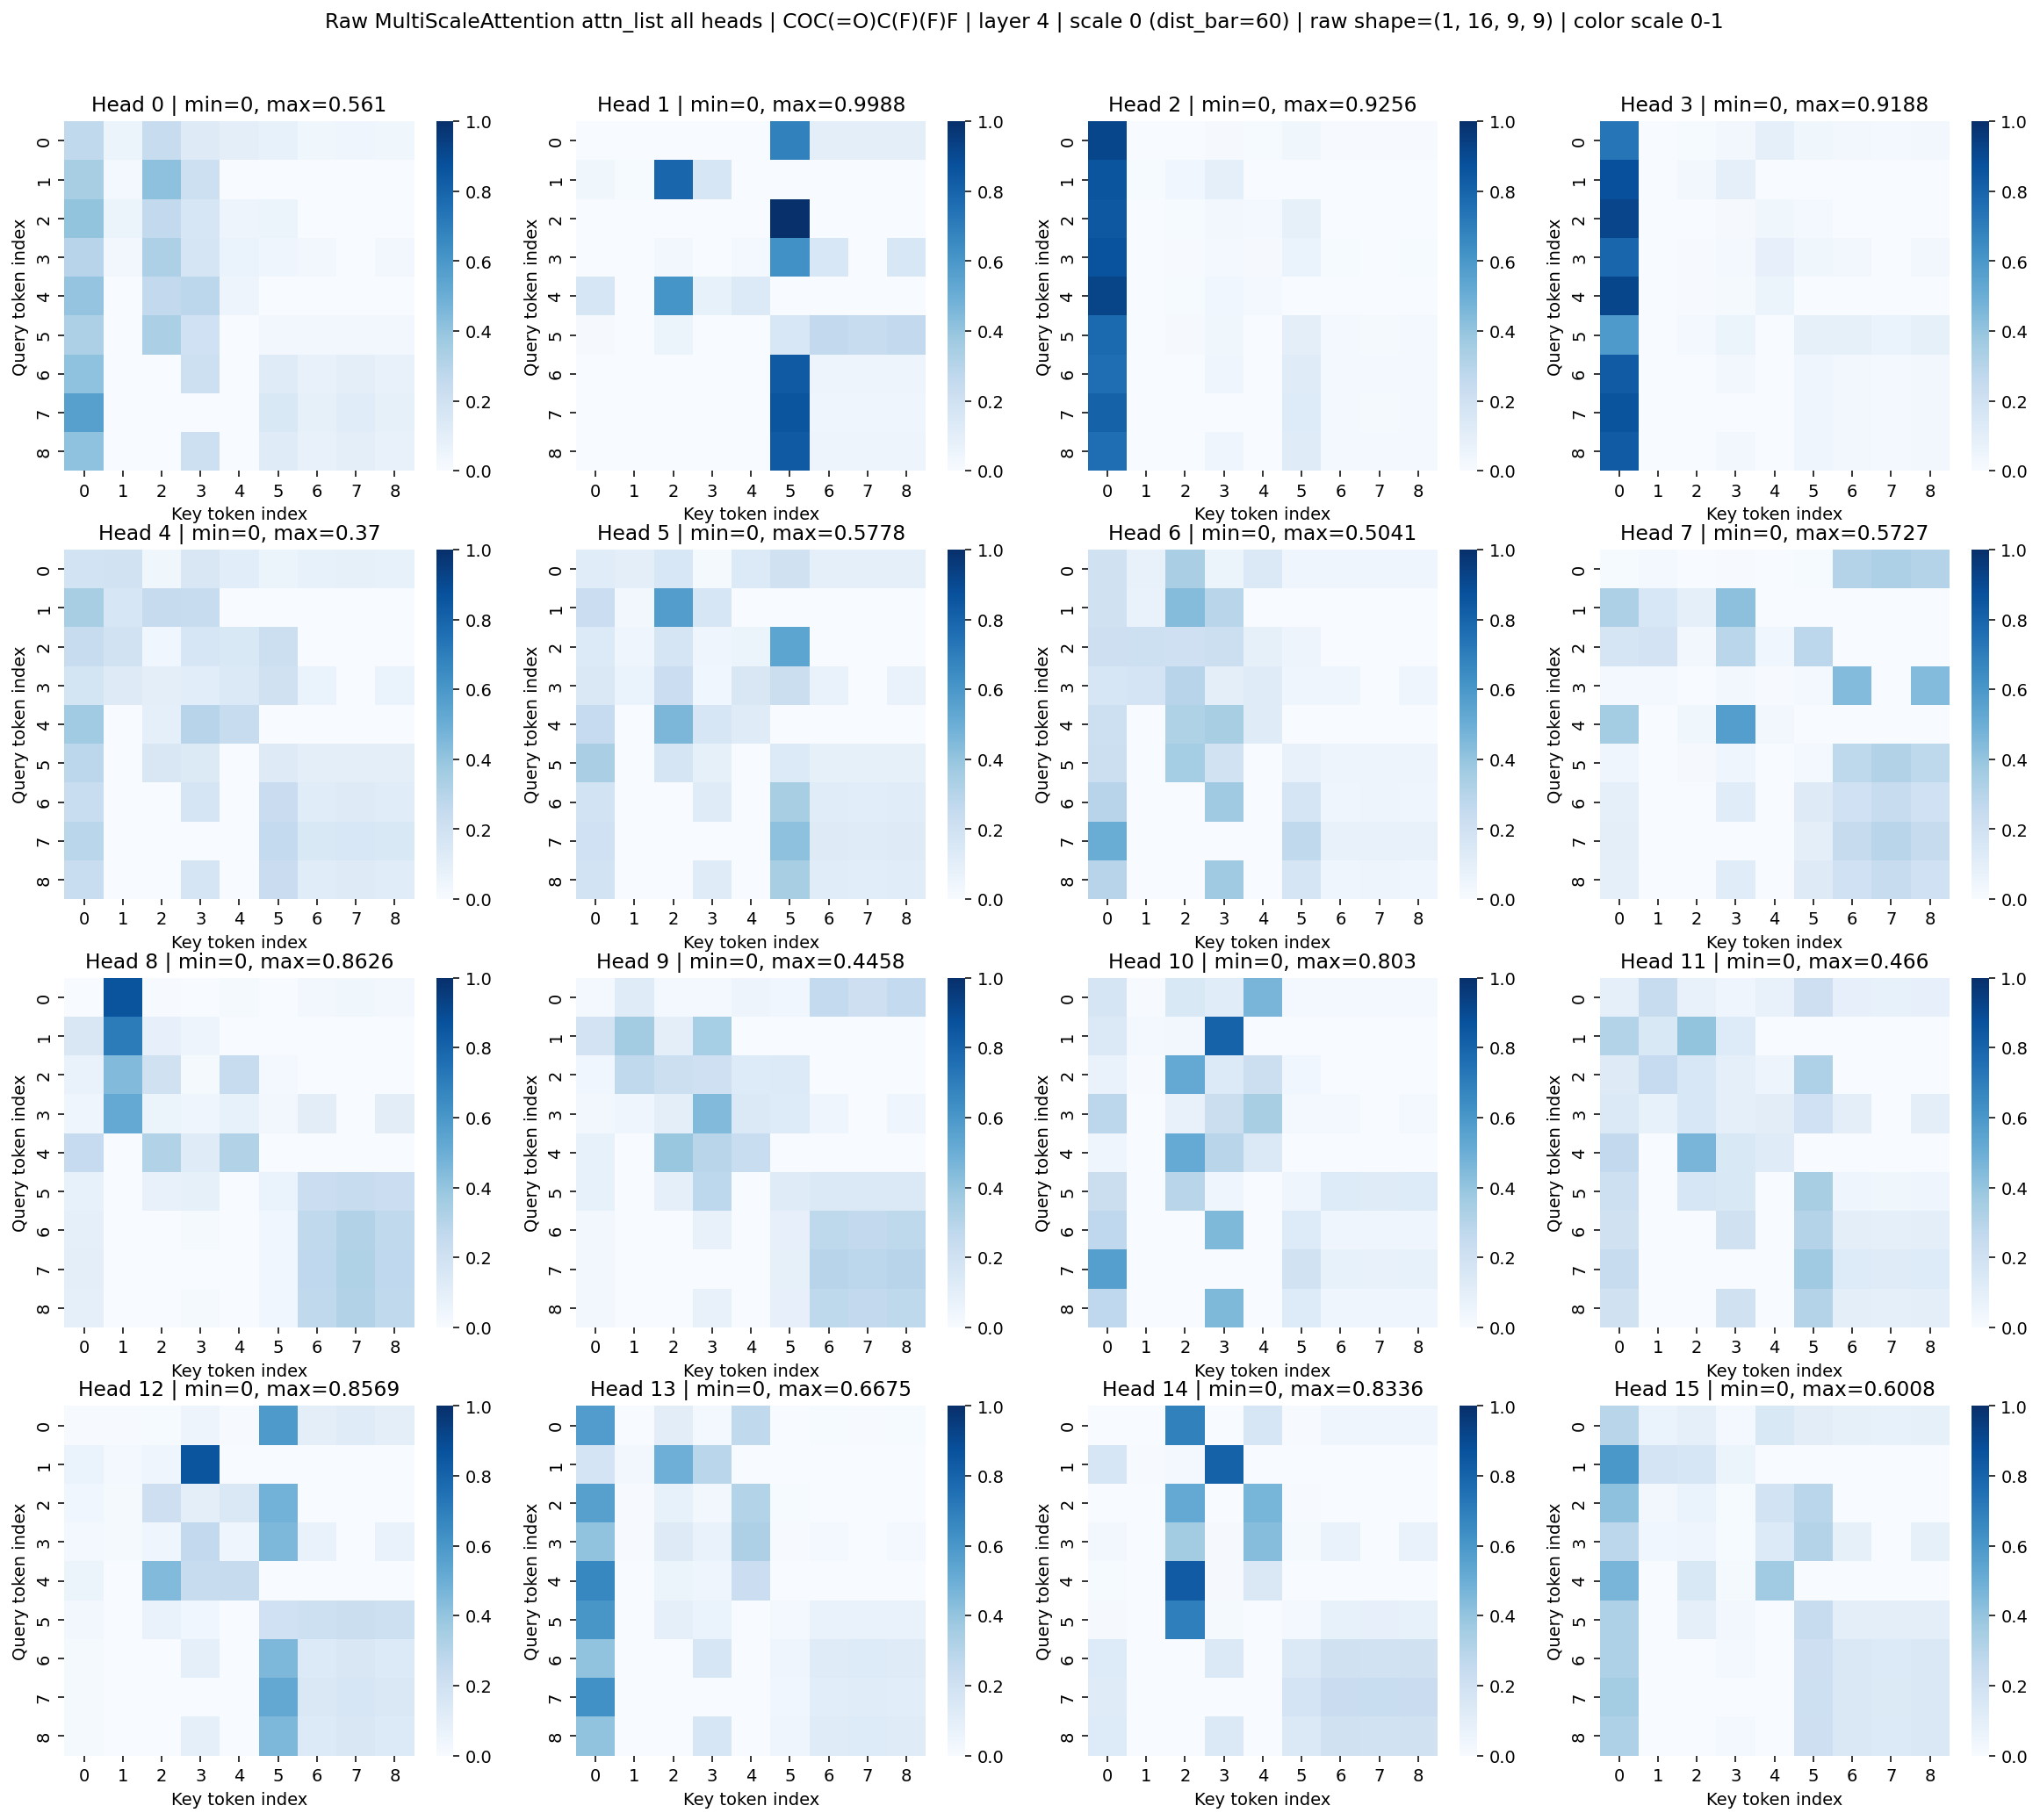

raw all-head attn layer=4, scale=0, dist_bar=60, shape=(1, 16, 9, 9), min=0, max=0.998782


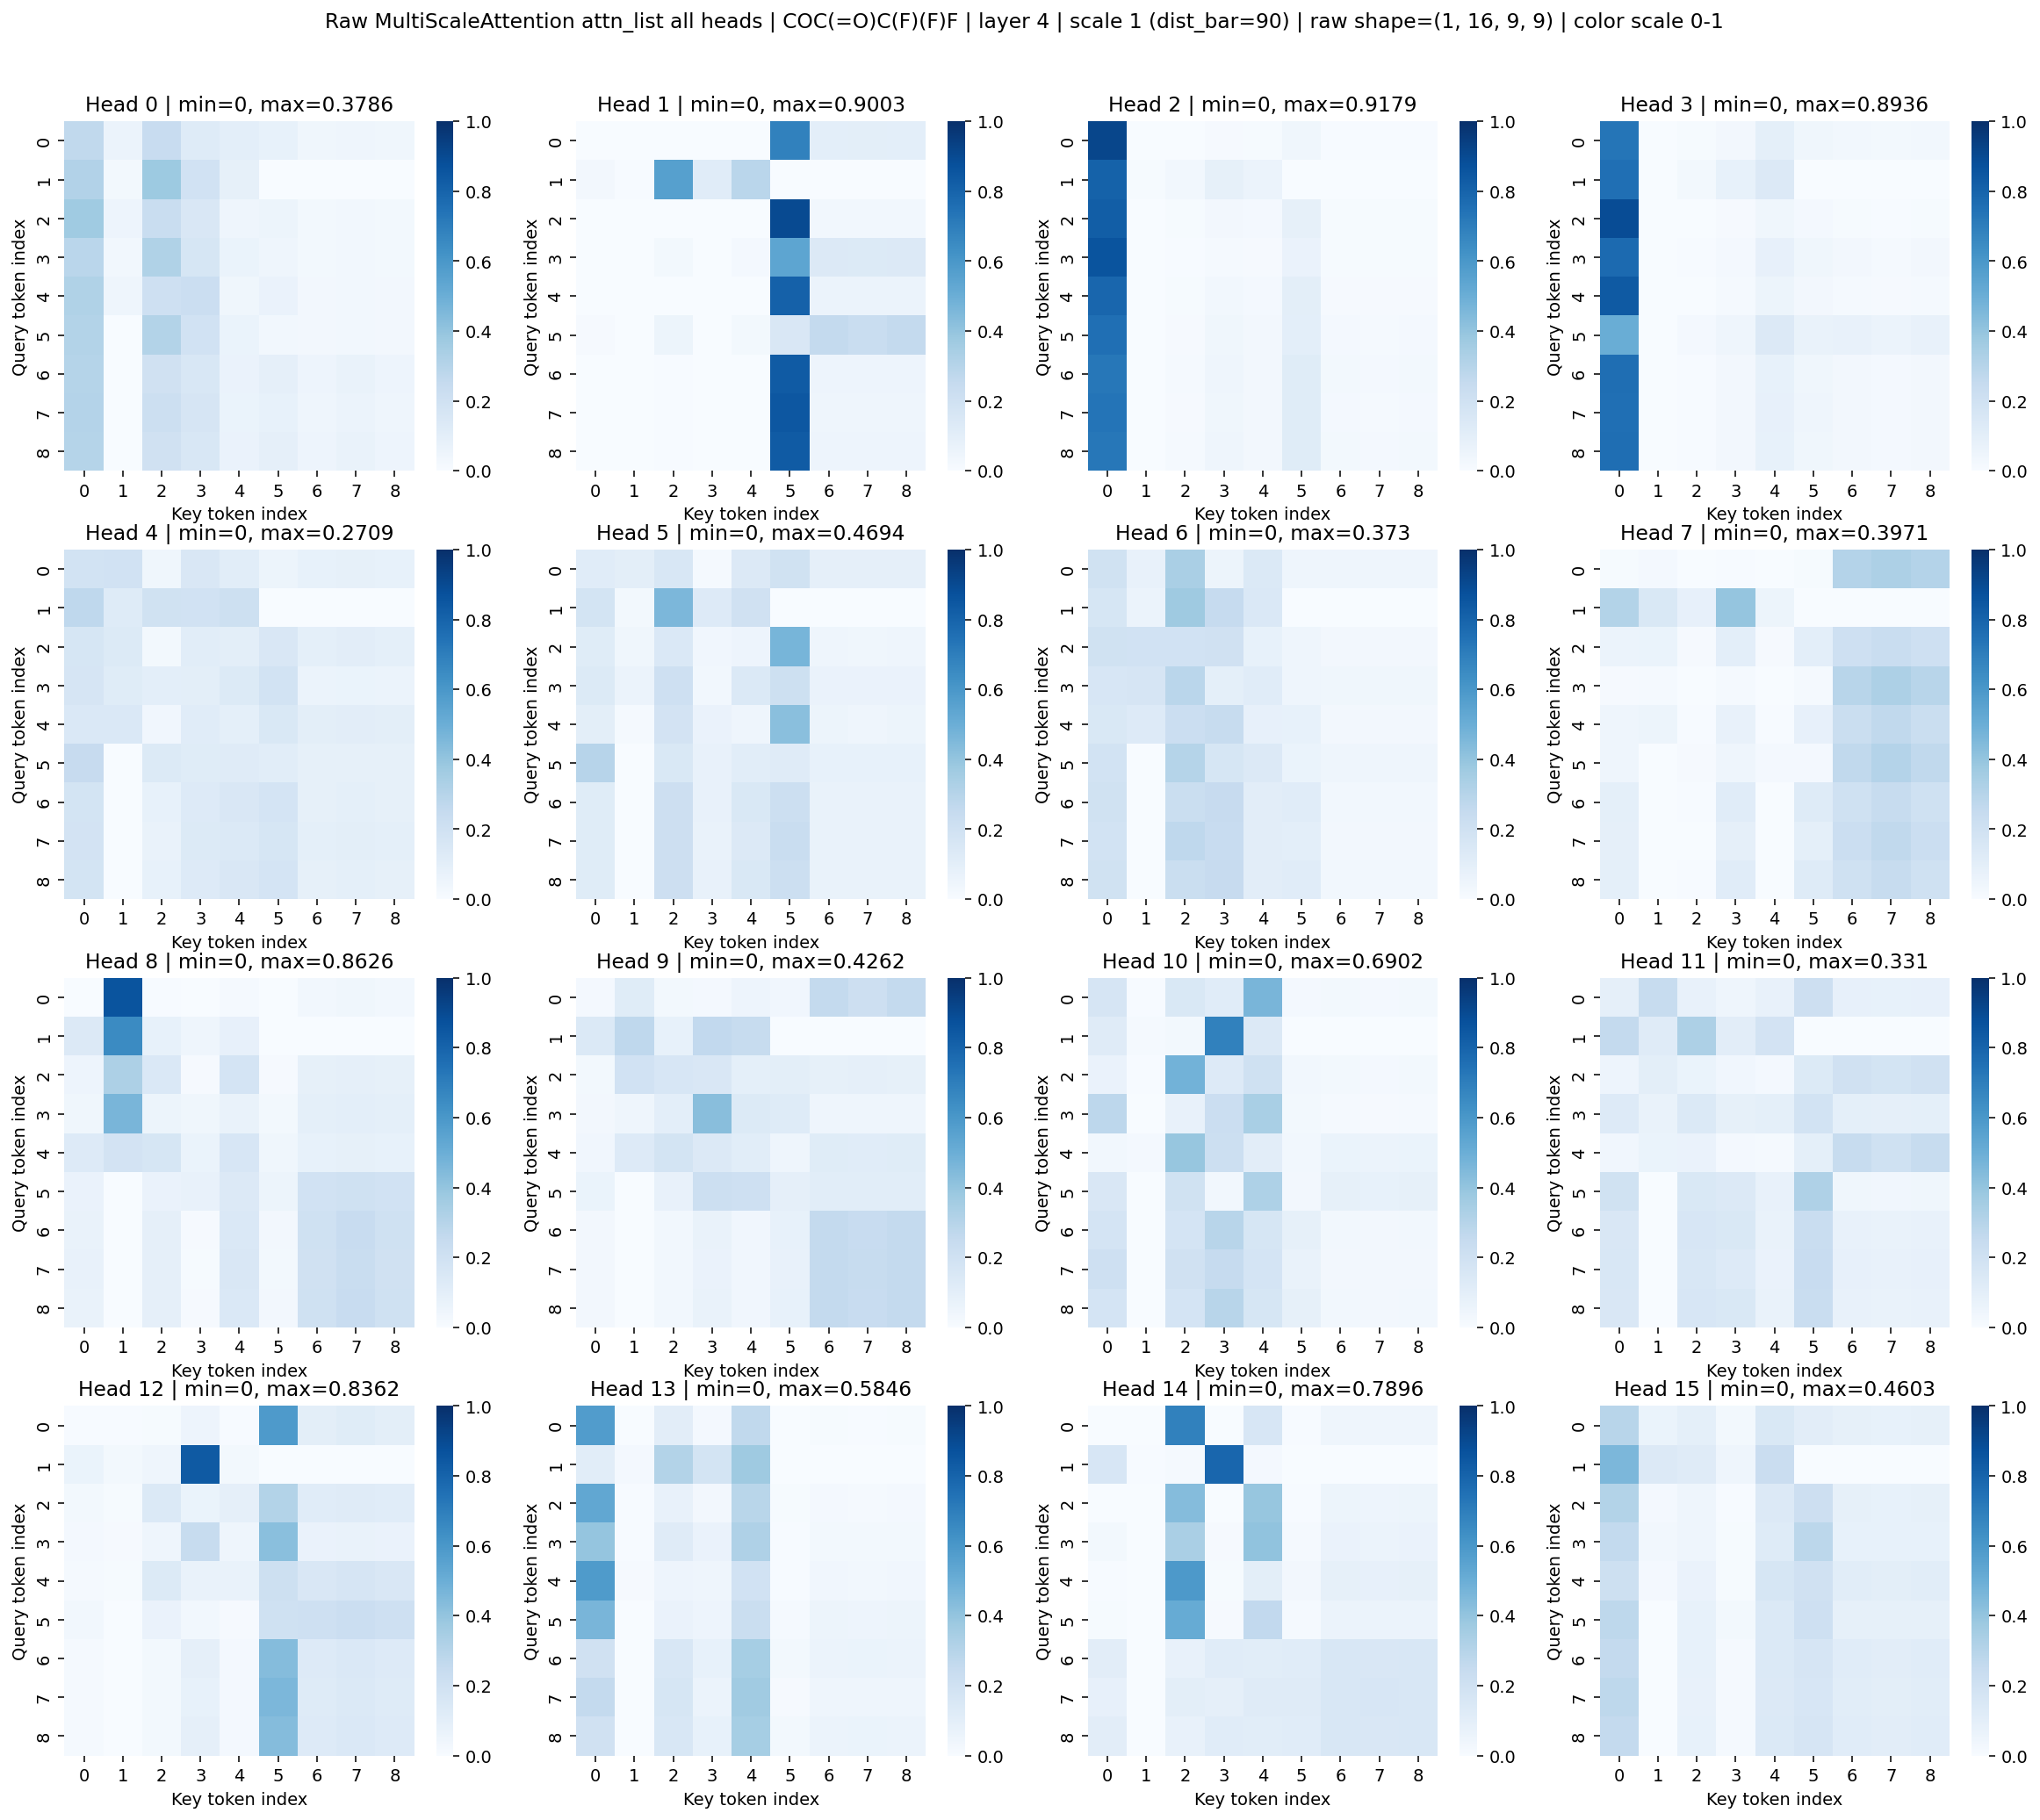

raw all-head attn layer=4, scale=1, dist_bar=90, shape=(1, 16, 9, 9), min=0, max=0.91785


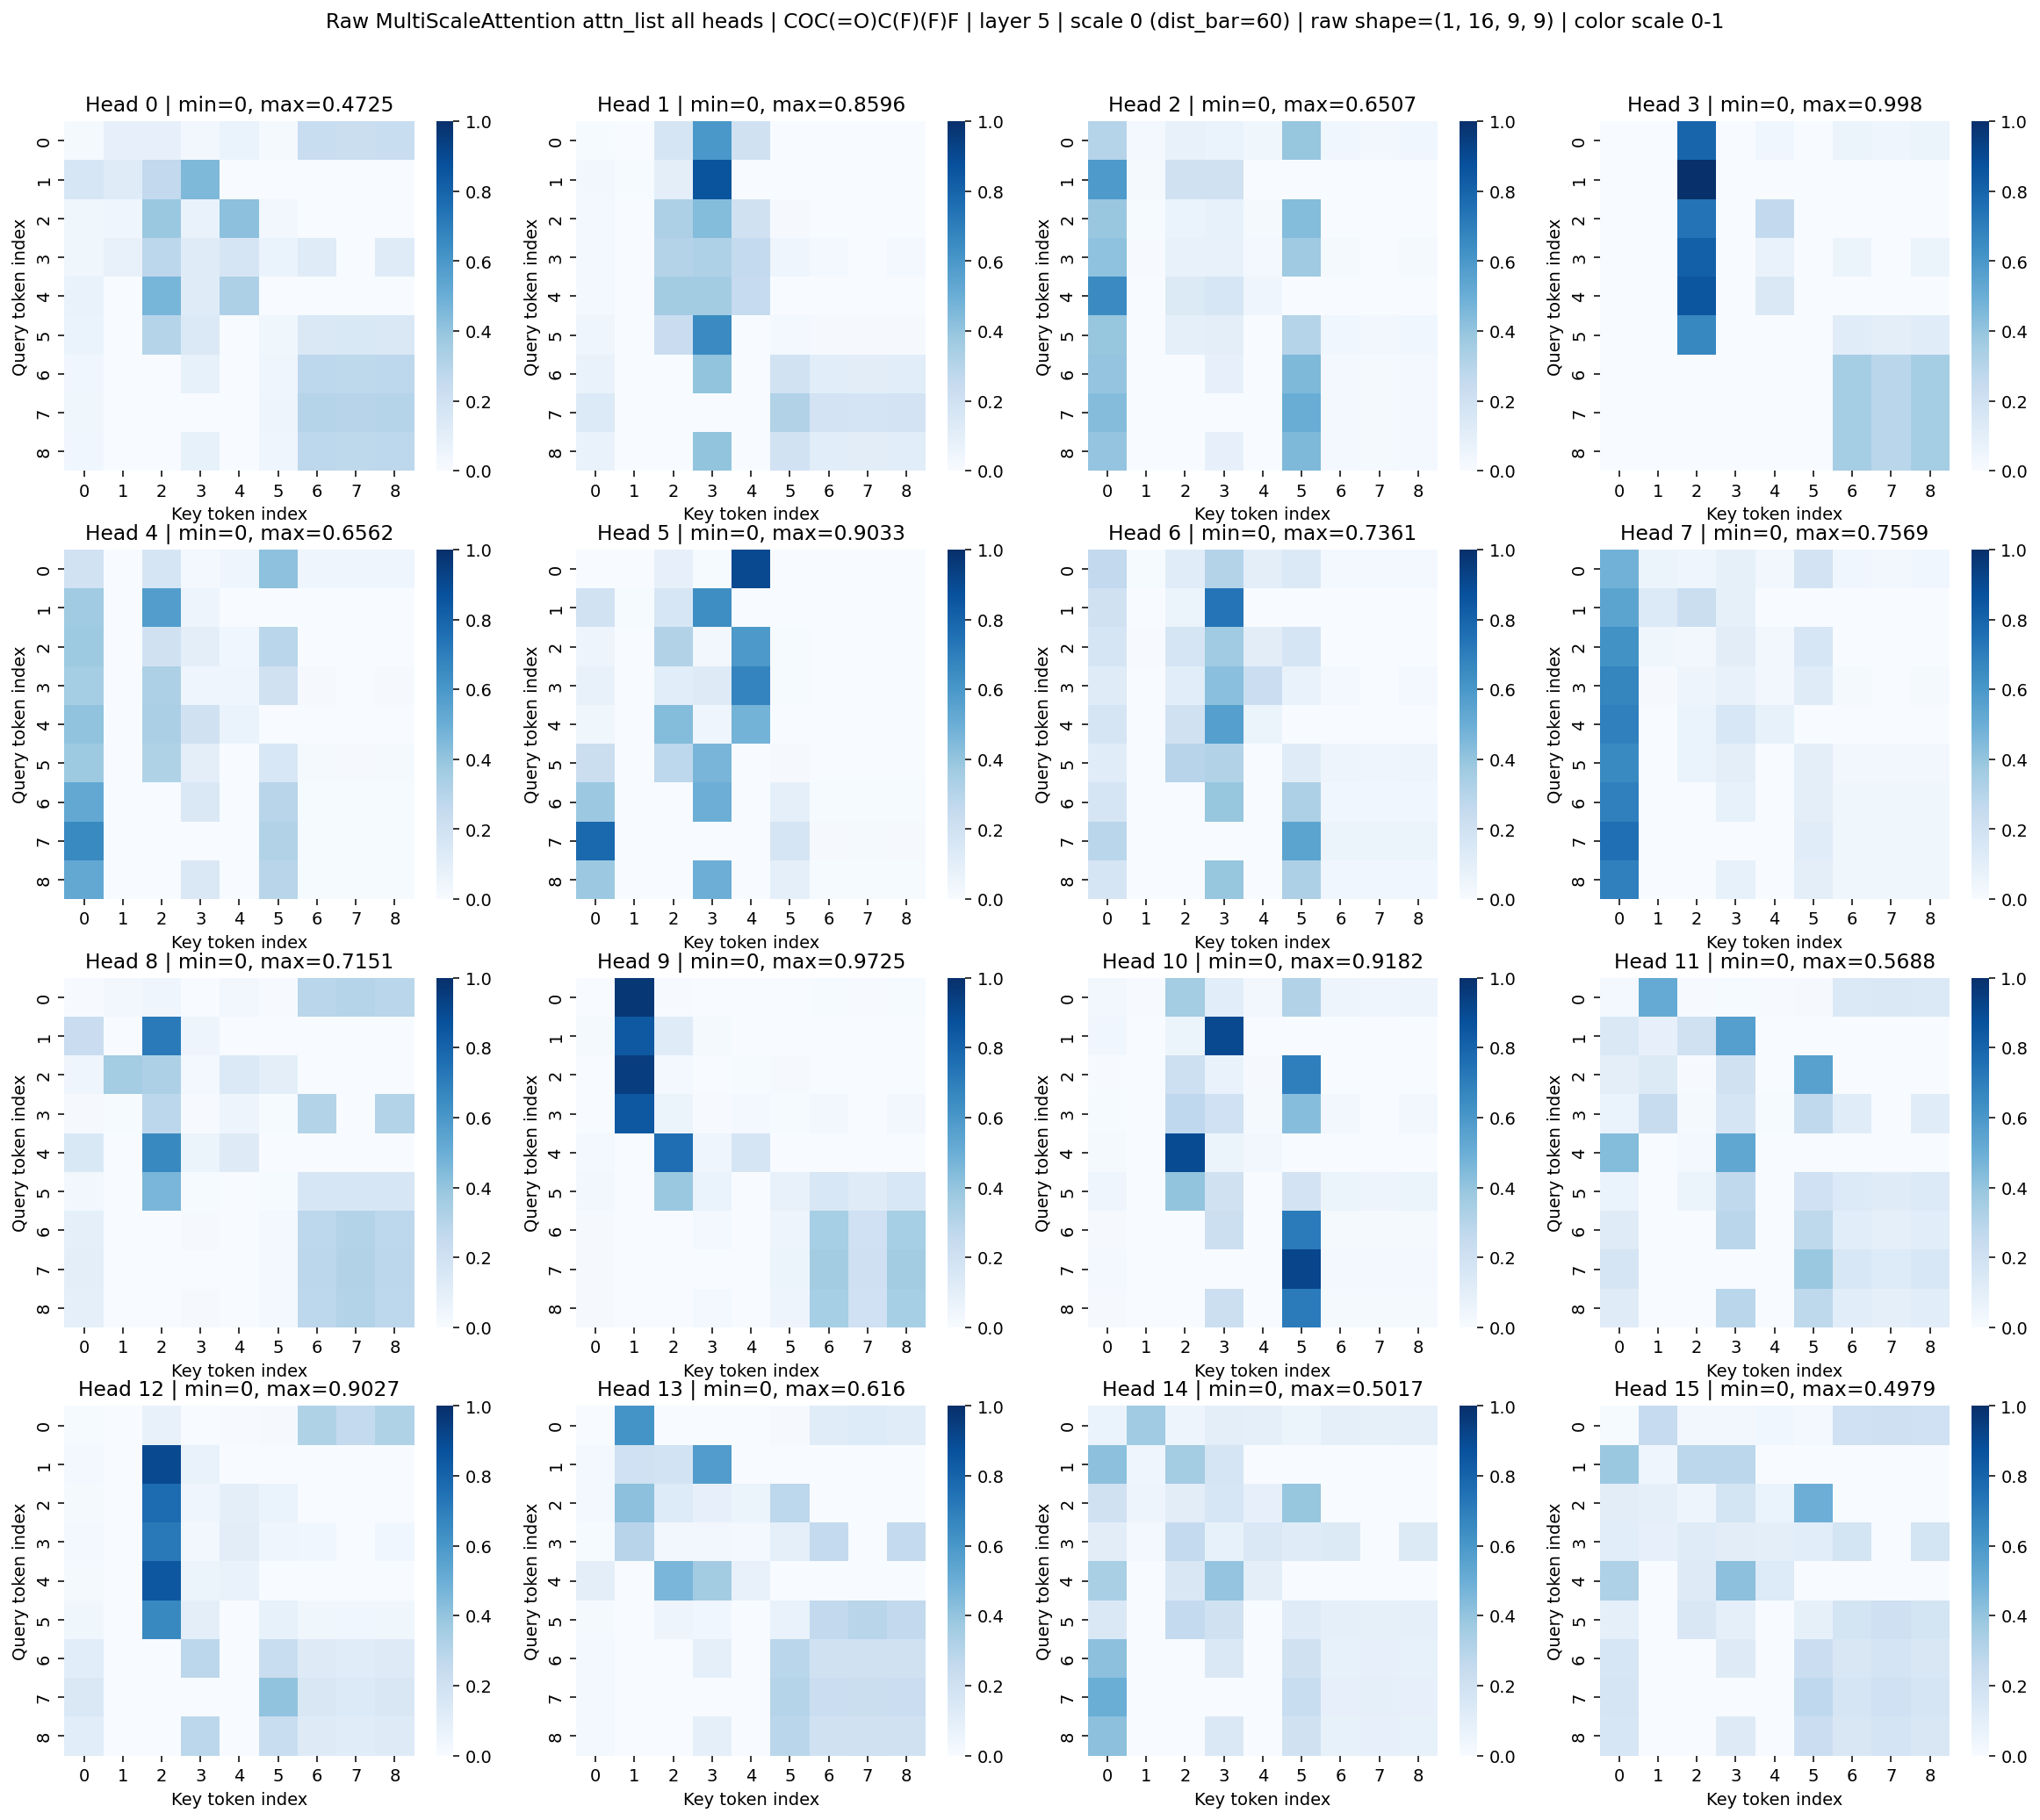

raw all-head attn layer=5, scale=0, dist_bar=60, shape=(1, 16, 9, 9), min=0, max=0.997994


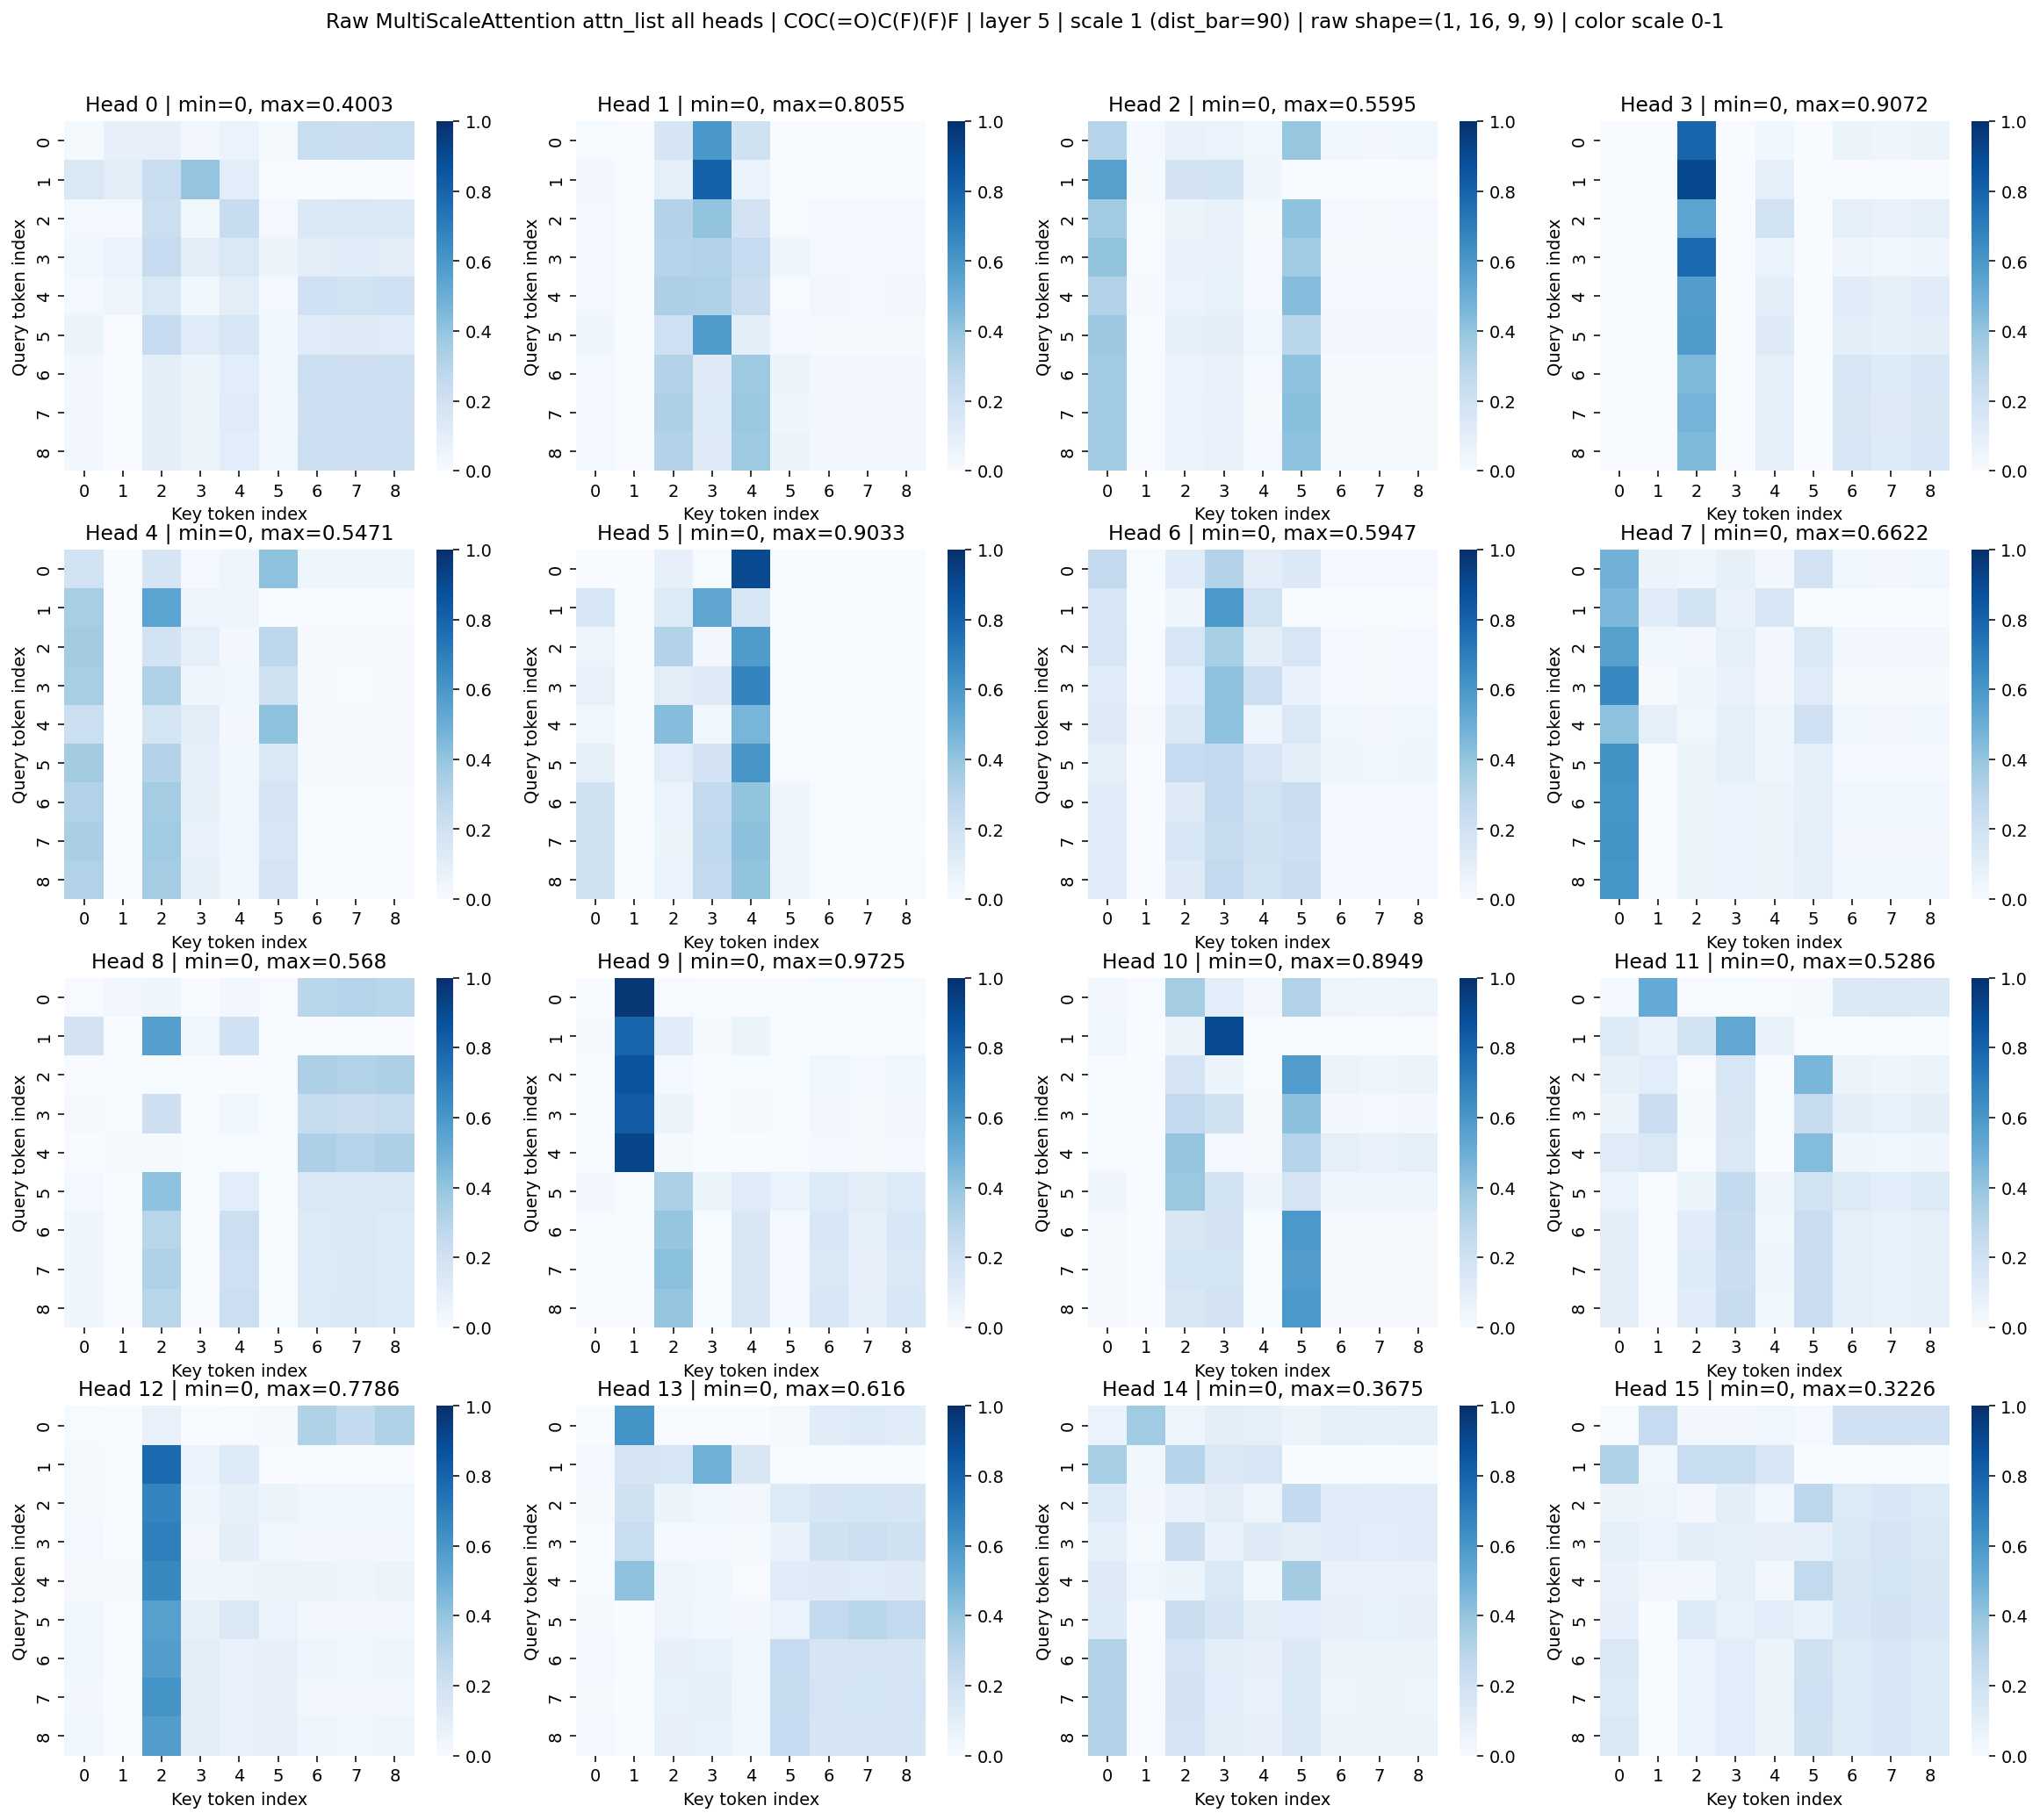

raw all-head attn layer=5, scale=1, dist_bar=90, shape=(1, 16, 9, 9), min=0, max=0.972506


In [8]:
raw_attn_all_head_figs = plot_raw_multiscale_attn_all_heads(
    attn_sink,
    title_prefix=f'Raw MultiScaleAttention attn_list all heads | {SMILES}',
)